# 🚢 Titanic Passenger Dataset – Exploratory Data Analysis

---

## Section 1 · Project Overview

**Project Title:** Exploratory Data Analysis of the Titanic Passenger Dataset
**Internship:** CodeAlpha Data Analytics Internship — Task 2
**Tool Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy
**Dataset:** Titanic Passenger Data (891 records, 15 variables)
**Source:** Seaborn built-in dataset (original data from Kaggle / Vanderbilt University Biostatistics)

---

This notebook performs a structured, end-to-end EDA on the Titanic passenger dataset.
It covers all five CodeAlpha Task 2 requirements:

| Requirement | Coverage |
|---|---|
| Ask meaningful questions | Section 4 — 10 analytical questions defined upfront |
| Explore structure and variables | Sections 7–8 — shape, types, distributions |
| Identify trends, patterns, anomalies | Sections 14–17 — univariate through outlier analysis |
| Test hypotheses statistically | Section 19 — chi-square, Mann-Whitney U, point-biserial |
| Detect and document data quality issues | Sections 9–12 — missing values, duplicates, cleaning decisions |


---

## Section 2 · Objective

**Primary Objective:**
To investigate the demographic, socioeconomic, and logistical factors that influenced
passenger survival during the Titanic disaster of April 15, 1912.

**Specific Goals:**
1. Characterize the passenger population by age, class, sex, and embarkation.
2. Identify and document all data quality issues present in the dataset.
3. Quantify survival disparities across key passenger groups.
4. Test whether observed differences in survival rates are statistically significant.
5. Derive practical insights for emergency preparedness analysis.


---

## Section 3 · Dataset Information

| Attribute | Value |
|---|---|
| Dataset Name | Titanic Passenger Survival Dataset |
| Source | Seaborn built-in / Kaggle (original: Vanderbilt Biostatistics) |
| Rows | 891 passengers |
| Columns | 15 variables |
| Time Period | April 10–15, 1912 |
| License | Public domain |

### Variable Dictionary

| Column | Type | Description |
|---|---|---|
| `survived` | int (binary) | 0 = died, 1 = survived |
| `pclass` | int (ordinal) | 1 = First, 2 = Second, 3 = Third |
| `sex` | str (nominal) | male / female |
| `age` | float | Age in years; **~20% missing** |
| `sibsp` | int | Siblings/spouses aboard |
| `parch` | int | Parents/children aboard |
| `fare` | float | Ticket price (£ sterling, 1912) |
| `embarked` | str (nominal) | C = Cherbourg, Q = Queenstown, S = Southampton |
| `class` | str | Categorical version of pclass |
| `who` | str | man / woman / child (derived) |
| `adult_male` | bool | True if adult male (derived) |
| `deck` | str | Cabin deck A–G; **~77% missing** |
| `embark_town` | str | Full embarkation town (derived) |
| `alive` | str | yes/no version of survived (derived) |
| `alone` | bool | True if traveling without family |


---

## Section 4 · Analytical Questions

Ten questions defined **before** analysis to guide the investigation:

| # | Question | Task 2 Requirement |
|---|---|---|
| Q1 | What is the overall survival rate, and how does it break down by passenger class? | Trends & Patterns |
| Q2 | Did gender significantly influence survival probability? Is this statistically significant? | Hypothesis Testing |
| Q3 | How is passenger age distributed, and how does age relate to survival? | Structure + Patterns |
| Q4 | What are the data quality issues — missing values, duplicates, ambiguous entries? | Data Quality |
| Q5 | How is fare distributed? Are there extreme outliers, and what do they represent? | Anomaly Detection |
| Q6 | Is there a statistically significant relationship between fare paid and survival? | Hypothesis Testing |
| Q7 | How do embarkation port, class, and fare interact? | Multivariate Analysis |
| Q8 | Did traveling with family improve or reduce survival odds? | Pattern Identification |
| Q9 | What does the correlation structure among numerical variables reveal? | Variable Relationships |
| Q10 | Does the combined effect of gender and class reveal survival patterns not visible from either alone? | Multivariate Analysis |


---

## Section 5 · Import Libraries


In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib
matplotlib.use('Agg')   # non-interactive backend — required for saving figures
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pointbiserialr, shapiro

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Visualization output directory (relative to notebook/)
VIZ_DIR = os.path.join('..', 'visualizations')
os.makedirs(VIZ_DIR, exist_ok=True)

print('Libraries loaded successfully.')
print('Pandas  :', pd.__version__)
print('NumPy   :', np.__version__)
print('Seaborn :', sns.__version__)
print('VIZ_DIR :', os.path.abspath(VIZ_DIR))


Libraries loaded successfully.
Pandas  : 2.1.4
NumPy   : 1.26.4
Seaborn : 0.13.2
VIZ_DIR : E:\Documents\Downloads\CodeAlpha_Task2_EDA\visualizations


---

## Section 6 · Load Dataset


In [2]:
# Load from local CSV (relative path from notebook/)
DATA_PATH = os.path.join('..', 'data', 'titanic.csv')
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()   # keep unmodified copy throughout

print('Dataset loaded from:', os.path.abspath(DATA_PATH))
print('Shape:', df.shape[0], 'rows x', df.shape[1], 'columns')


Dataset loaded from: E:\Documents\Downloads\CodeAlpha_Task2_EDA\data\titanic.csv
Shape: 891 rows x 15 columns


In [3]:
# First 10 rows
df.head(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.46,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.00,0,0,51.86,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.00,3,1,21.07,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.00,0,2,11.13,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.00,1,0,30.07,C,Second,child,False,NaN,Cherbourg,yes,False


---

## Section 7 · Initial Data Inspection


In [4]:
print('=== SHAPE ===')
print('Rows   :', df.shape[0])
print('Cols   :', df.shape[1])
print()
print('=== COLUMNS ===')
print(list(df.columns))
print()
print('=== FIRST 5 ROWS ===')
print(df.head().to_string())


=== SHAPE ===
Rows   : 891
Cols   : 15

=== COLUMNS ===
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

=== FIRST 5 ROWS ===
   survived  pclass     sex   age  sibsp  parch  fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male 22.00      1      0  7.25        S  Third    man        True  NaN  Southampton    no  False
1         1       1  female 38.00      1      0 71.28        C  First  woman       False    C    Cherbourg   yes  False
2         1       3  female 26.00      0      0  7.92        S  Third  woman       False  NaN  Southampton   yes   True
3         1       1  female 35.00      1      0 53.10        S  First  woman       False    C  Southampton   yes  False
4         0       3    male 35.00      0      0  8.05        S  Third    man        True  NaN  Southampton    no   True


In [5]:
print('=== LAST 5 ROWS ===')
print(df.tail().to_string())


=== LAST 5 ROWS ===
     survived  pclass     sex   age  sibsp  parch  fare embarked   class    who  adult_male deck  embark_town alive  alone
886         0       2    male 27.00      0      0 13.00        S  Second    man        True  NaN  Southampton    no   True
887         1       1  female 19.00      0      0 30.00        S   First  woman       False    B  Southampton   yes   True
888         0       3  female   NaN      1      2 23.45        S   Third  woman       False  NaN  Southampton    no  False
889         1       1    male 26.00      0      0 30.00        C   First    man        True    C    Cherbourg   yes   True
890         0       3    male 32.00      0      0  7.75        Q   Third    man        True  NaN   Queenstown    no   True


In [6]:
print('=== RANDOM SAMPLE (n=8, seed=42) ===')
print(df.sample(8, random_state=42).to_string())


=== RANDOM SAMPLE (n=8, seed=42) ===
     survived  pclass     sex   age  sibsp  parch  fare embarked   class    who  adult_male deck  embark_town alive  alone
709         1       3    male   NaN      1      1 15.25        C   Third    man        True  NaN    Cherbourg   yes  False
439         0       2    male 31.00      0      0 10.50        S  Second    man        True  NaN  Southampton    no   True
840         0       3    male 20.00      0      0  7.92        S   Third    man        True  NaN  Southampton    no   True
720         1       2  female  6.00      0      1 33.00        S  Second  child       False  NaN  Southampton   yes  False
39          1       3  female 14.00      1      0 11.24        C   Third  child       False  NaN    Cherbourg   yes  False
290         1       1  female 26.00      0      0 78.85        S   First  woman       False  NaN  Southampton   yes   True
300         1       3  female   NaN      0      0  7.75        Q   Third  woman       False  NaN   Que

---

## Section 8 · Data Structure and Data Types


In [7]:
print('=== DTYPES AND NON-NULL COUNTS ===')
df.info()


=== DTYPES AND NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [8]:
print('=== VALUE COUNTS — CATEGORICAL COLUMNS ===')
cat_cols = df.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False).to_string())


=== VALUE COUNTS — CATEGORICAL COLUMNS ===

--- sex ---
sex
male      577
female    314

--- embarked ---
embarked
S      644
C      168
Q       77
NaN      2

--- class ---
class
Third     491
First     216
Second    184

--- who ---
who
man      537
woman    271
child     83

--- adult_male ---
adult_male
True     537
False    354

--- deck ---
deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4

--- embark_town ---
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2

--- alive ---
alive
no     549
yes    342

--- alone ---
alone
True     537
False    354


In [9]:
print('=== UNIQUE VALUES PER COLUMN ===')
uq = df.nunique().reset_index()
uq.columns = ['Column', 'Unique']
uq['Pct'] = (uq['Unique'] / len(df) * 100).round(1)
print(uq.to_string(index=False))


=== UNIQUE VALUES PER COLUMN ===
     Column  Unique   Pct
   survived       2  0.20
     pclass       3  0.30
        sex       2  0.20
        age      88  9.90
      sibsp       7  0.80
      parch       7  0.80
       fare     248 27.80
   embarked       3  0.30
      class       3  0.30
        who       3  0.30
 adult_male       2  0.20
       deck       7  0.80
embark_town       3  0.30
      alive       2  0.20
      alone       2  0.20


---

## Section 9 · Data Quality Analysis

Documenting all data quality issues **before** any cleaning.


In [10]:
print('=== REDUNDANT / DERIVED COLUMNS ===')
print("  'class'       — categorical duplicate of 'pclass'")
print("  'alive'       — string duplicate of 'survived'")
print("  'embark_town' — full-text duplicate of 'embarked'")
print("  'who'         — derived from sex + age")
print("  'adult_male'  — derived from sex + age")
print('  Decision: DROP before analysis to avoid confusion and multicollinearity.')


=== REDUNDANT / DERIVED COLUMNS ===
  'class'       — categorical duplicate of 'pclass'
  'alive'       — string duplicate of 'survived'
  'embark_town' — full-text duplicate of 'embarked'
  'who'         — derived from sex + age
  'adult_male'  — derived from sex + age
  Decision: DROP before analysis to avoid confusion and multicollinearity.


In [11]:
print('=== MISSING VALUES ===')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Count': miss, 'Pct': miss_pct})
miss_df = miss_df[miss_df['Count'] > 0].sort_values('Pct', ascending=False)
print(miss_df.to_string())
print()
total_miss = df.isnull().sum().sum()
print(f'Total missing cells : {total_miss}  ({total_miss / df.size * 100:.1f}% of all cells)')


=== MISSING VALUES ===
             Count   Pct
deck           688 77.20
age            177 19.90
embarked         2  0.20
embark_town      2  0.20

Total missing cells : 869  (6.5% of all cells)


In [12]:
print('=== DUPLICATE ROWS ===')
n_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes}')
if n_dupes == 0:
    print('No exact duplicates found.')


=== DUPLICATE ROWS ===
Exact duplicate rows: 107


In [13]:
print('=== SUSPICIOUS / ANOMALOUS VALUES ===')
print()
age_out = df[(df['age'] < 0) | (df['age'] > 100)]
print(f'Age outside [0, 100]: {len(age_out)}')

fare_neg = df[df['fare'] < 0]
print(f'Negative fares      : {len(fare_neg)}')

zero_fare = df[df['fare'] == 0]
print(f'Zero fares          : {len(zero_fare)}')
if len(zero_fare) > 0:
    print()
    print('Zero-fare passengers:')
    print(zero_fare[['pclass', 'sex', 'age', 'fare', 'embarked', 'survived']].to_string())

print()
print(f'Max SibSp: {df["sibsp"].max()}  |  Max Parch: {df["parch"].max()}')
print()
print('Passengers with SibSp >= 5:')
print(df[df['sibsp'] >= 5][['pclass', 'sex', 'age', 'sibsp', 'parch', 'survived']].to_string())


=== SUSPICIOUS / ANOMALOUS VALUES ===

Age outside [0, 100]: 0
Negative fares      : 0
Zero fares          : 15

Zero-fare passengers:
     pclass   sex   age  fare embarked  survived
179       3  male 36.00  0.00        S         0
263       1  male 40.00  0.00        S         0
271       3  male 25.00  0.00        S         1
277       2  male   NaN  0.00        S         0
302       3  male 19.00  0.00        S         0
413       2  male   NaN  0.00        S         0
466       2  male   NaN  0.00        S         0
481       2  male   NaN  0.00        S         0
597       3  male 49.00  0.00        S         0
633       1  male   NaN  0.00        S         0
674       2  male   NaN  0.00        S         0
732       2  male   NaN  0.00        S         0
806       1  male 39.00  0.00        S         0
815       1  male   NaN  0.00        S         0
822       1  male 38.00  0.00        S         0

Max SibSp: 8  |  Max Parch: 6

Passengers with SibSp >= 5:
     pclass     sex  

---

## Section 10 · Missing Value Analysis


Saved: 05_missing_values_heatmap.png


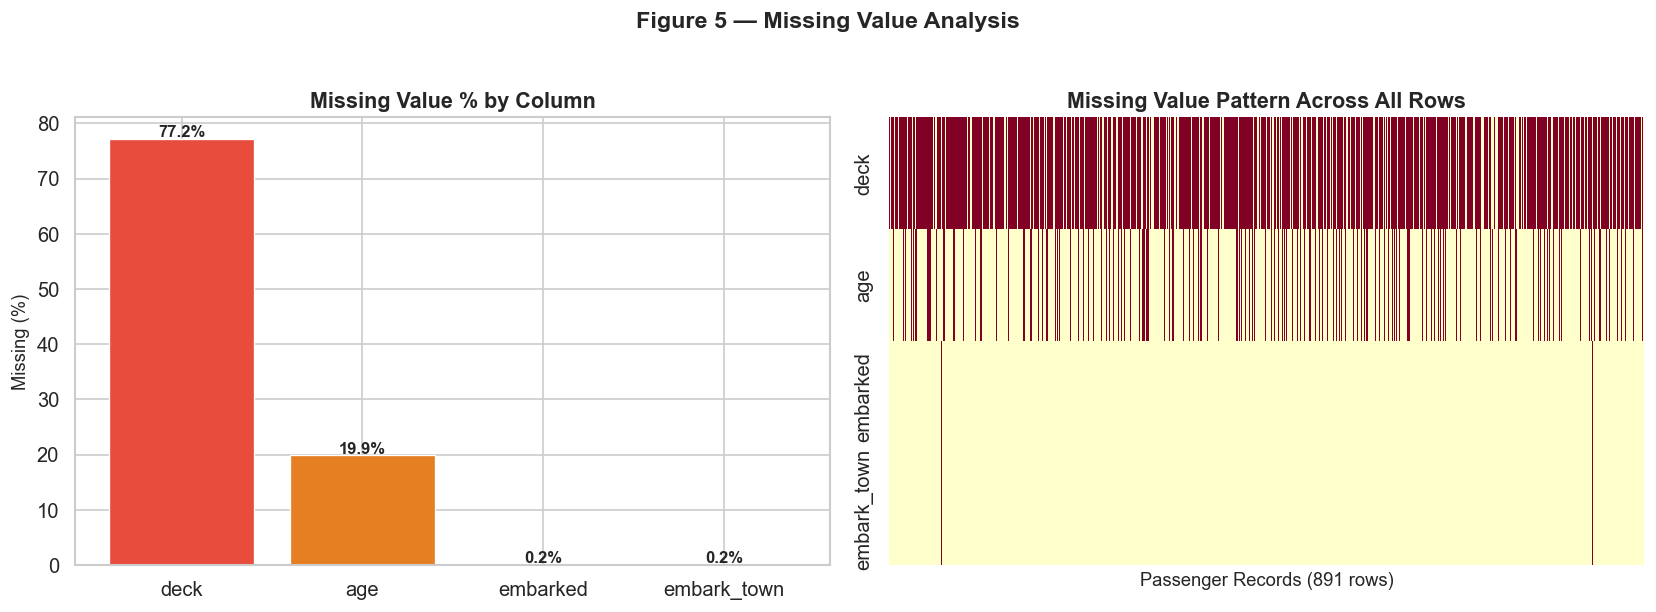

In [14]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

miss_cols = df.isnull().sum()
miss_cols = miss_cols[miss_cols > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['#e74c3c', '#e67e22', '#f1c40f']
axes[0].bar(miss_cols.index, miss_cols.values / len(df) * 100,
            color=bar_colors[:len(miss_cols)], edgecolor='white', linewidth=0.8)
axes[0].set_title('Missing Value % by Column', fontweight='bold')
axes[0].set_ylabel('Missing (%)')
for i, v in enumerate(miss_cols.values / len(df) * 100):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

miss_pattern = df[miss_cols.index].isnull()
sns.heatmap(miss_pattern.T, cbar=False, yticklabels=True,
            xticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Value Pattern Across All Rows', fontweight='bold')
axes[1].set_xlabel('Passenger Records (891 rows)')

plt.suptitle('Figure 5 — Missing Value Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '05_missing_values_heatmap.png'))
plt.show()
print('Saved: 05_missing_values_heatmap.png')


In [15]:
# Is age missingness systematic or random (MCAR)?
df['age_missing'] = df['age'].isnull().astype(int)

print('Survival rate — age missing vs present:')
print(df.groupby('age_missing')['survived'].agg(['mean', 'count']).rename(
    columns={'mean': 'Survival Rate', 'count': 'N'}).to_string())
print()
print('Pclass distribution — age missing vs present:')
print(df.groupby('age_missing')['pclass'].value_counts(normalize=True).unstack().round(3).to_string())
print()
print('Conclusion: Age is more missing in 3rd class — NOT purely random (MAR, not MCAR).')
print('Implication: Global mean imputation would be biased; group-level median is preferred.')


Survival rate — age missing vs present:
             Survival Rate    N
age_missing                    
0                     0.41  714
1                     0.29  177

Pclass distribution — age missing vs present:
pclass         1    2    3
age_missing               
0           0.26 0.24 0.50
1           0.17 0.06 0.77

Conclusion: Age is more missing in 3rd class — NOT purely random (MAR, not MCAR).
Implication: Global mean imputation would be biased; group-level median is preferred.


---

## Section 11 · Duplicate Analysis


In [16]:
print('=== DUPLICATE ANALYSIS ===')
n_exact = df.duplicated().sum()
print(f'Exact duplicate rows: {n_exact}')
print()

key_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
n_key_dupes = df.duplicated(subset=key_cols).sum()
print(f'Near-duplicate rows (same on 7 key fields): {n_key_dupes}')
print()

if n_key_dupes > 0:
    dupes = df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)
    print('Sample near-duplicates (likely family members with matching attributes):')
    print(dupes[key_cols + ['survived']].head(10).to_string())
    print()
    print('Decision: Near-duplicates are NOT removed — they are legitimate passengers.')


=== DUPLICATE ANALYSIS ===
Exact duplicate rows: 107

Near-duplicate rows (same on 7 key fields): 127

Sample near-duplicates (likely family members with matching attributes):
     pclass     sex   age  sibsp  parch  fare embarked  survived
369       1  female 24.00      0      0 69.30        C         1
641       1  female 24.00      0      0 69.30        C         1
187       1    male 45.00      0      0 26.55        S         1
536       1    male 45.00      0      0 26.55        S         0
252       1    male 62.00      0      0 26.55        S         0
555       1    male 62.00      0      0 26.55        S         0
633       1    male   NaN      0      0  0.00        S         0
815       1    male   NaN      0      0  0.00        S         0
507       1    male   NaN      0      0 26.55        S         1
711       1    male   NaN      0      0 26.55        S         0

Decision: Near-duplicates are NOT removed — they are legitimate passengers.


---

## Section 12 · Data Cleaning

Every cleaning decision is documented with justification.
No rows or columns are removed without explicit reasoning.


In [17]:
# ── DECISION 1: Drop redundant / derived columns ─────────────────────────────
cols_to_drop = ['class', 'alive', 'embark_town', 'who', 'adult_male', 'age_missing']
df_clean = df.drop(columns=cols_to_drop)
print('DECISION 1: Dropped 6 redundant/derived columns.')
print('  Reason: carry no independent information — derived from retained columns.')
print('  Shape after:', df_clean.shape)
print()

# ── DECISION 2: Impute missing Age with pclass×sex group median ───────────────
age_medians = df_clean.groupby(['pclass', 'sex'])['age'].transform('median')
df_clean['age'] = df_clean['age'].fillna(age_medians)
print('DECISION 2: Imputed missing Age using pclass×sex group median.')
print('  Reason: 20% missing — dropping 177 rows loses too much data.')
print('  Group median chosen over global mean because age is right-skewed')
print('  and distributions differ significantly by class and sex.')
print('  Group medians used:')
print(df.groupby(['pclass', 'sex'])['age'].median().to_string())
print('  Remaining missing Age:', df_clean['age'].isnull().sum())
print()

# ── DECISION 3: Drop 2 rows with missing Embarked ─────────────────────────────
n_before = len(df_clean)
df_clean = df_clean.dropna(subset=['embarked'])
print('DECISION 3: Dropped', n_before - len(df_clean), 'rows with missing Embarked.')
print('  Reason: Only 2 rows — negligible loss (0.22%). Imputing port for 2 rows')
print('  would introduce arbitrary uncertainty.')
print('  Shape after:', df_clean.shape)
print()

# ── DECISION 4: Drop Deck column ──────────────────────────────────────────────
df_clean = df_clean.drop(columns=['deck'])
print('DECISION 4: Dropped "deck" column (77.2% missing).')
print('  Reason: Not analytically recoverable — any imputation would be fabricated.')
print('  Shape after:', df_clean.shape)
print()

# ── DECISION 5: Retain zero-fare passengers ───────────────────────────────────
n_zero = (df_clean['fare'] == 0).sum()
print('DECISION 5: Retained', n_zero, 'zero-fare passengers (flagged as anomalous).')
print('  Reason: Likely crew/officer records. Removing them would lose valid data.')
print()

# ── DECISION 6: Feature engineering — family_size and is_alone ────────────────
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)
print('DECISION 6: Engineered family_size = sibsp + parch + 1')
print('  is_alone = 1 if traveling solo, else 0')
print('  Family size range:', df_clean['family_size'].min(), '–', df_clean['family_size'].max())
print()

print('=== FINAL CLEAN DATASET ===')
print('Shape:', df_clean.shape)
print('Columns:', list(df_clean.columns))
rem = df_clean.isnull().sum()
rem = rem[rem > 0]
if len(rem) == 0:
    print('Remaining missing values: NONE')
else:
    print('Remaining missing values:')
    print(rem.to_string())


DECISION 1: Dropped 6 redundant/derived columns.
  Reason: carry no independent information — derived from retained columns.
  Shape after: (891, 10)

DECISION 2: Imputed missing Age using pclass×sex group median.
  Reason: 20% missing — dropping 177 rows loses too much data.
  Group median chosen over global mean because age is right-skewed
  and distributions differ significantly by class and sex.
  Group medians used:
pclass  sex   
1       female   35.00
        male     40.00
2       female   28.00
        male     30.00
3       female   21.50
        male     25.00
  Remaining missing Age: 0

DECISION 3: Dropped 2 rows with missing Embarked.
  Reason: Only 2 rows — negligible loss (0.22%). Imputing port for 2 rows
  would introduce arbitrary uncertainty.
  Shape after: (889, 10)

DECISION 4: Dropped "deck" column (77.2% missing).
  Reason: Not analytically recoverable — any imputation would be fabricated.
  Shape after: (889, 9)

DECISION 5: Retained 15 zero-fare passengers (flag

In [18]:
# Verify cleaned data looks correct
df_clean.head(8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,family_size,is_alone
0,0,3,male,22.00,1,0,7.25,S,False,2,0
1,1,1,female,38.00,1,0,71.28,C,False,2,0
2,1,3,female,26.00,0,0,7.92,S,True,1,1
3,1,1,female,35.00,1,0,53.10,S,False,2,0
4,0,3,male,35.00,0,0,8.05,S,True,1,1
5,0,3,male,25.00,0,0,8.46,Q,True,1,1
6,0,1,male,54.00,0,0,51.86,S,True,1,1
7,0,3,male,2.00,3,1,21.07,S,False,5,0


---

## Section 13 · Descriptive Statistics


In [19]:
num_cols = ['age', 'fare', 'sibsp', 'parch', 'family_size']
desc = df_clean[num_cols].describe().T
desc['skewness'] = df_clean[num_cols].skew().round(2)
desc['kurtosis'] = df_clean[num_cols].kurt().round(2)
print('=== NUMERICAL DESCRIPTIVE STATISTICS ===')
print(desc.round(2).to_string())


=== NUMERICAL DESCRIPTIVE STATISTICS ===
             count  mean   std  min   25%   50%   75%    max  skewness  kurtosis
age         889.00 29.07 13.27 0.42 21.50 26.00 36.00  80.00      0.53      0.73
fare        889.00 32.10 49.70 0.00  7.90 14.45 31.00 512.33      4.80     33.51
sibsp       889.00  0.52  1.10 0.00  0.00  0.00  1.00   8.00      3.69     17.84
parch       889.00  0.38  0.81 0.00  0.00  0.00  0.00   6.00      2.75      9.75
family_size 889.00  1.91  1.61 1.00  1.00  1.00  2.00  11.00      2.72      9.14


In [20]:
print('=== CATEGORICAL COLUMN DISTRIBUTIONS ===')
for col in ['survived', 'pclass', 'sex', 'embarked']:
    vc = df_clean[col].value_counts()
    pct = df_clean[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': vc, 'Pct (%)': pct.round(1)})
    print(f'\n--- {col.upper()} ---')
    print(summary.to_string())


=== CATEGORICAL COLUMN DISTRIBUTIONS ===

--- SURVIVED ---
          Count  Pct (%)
survived                
0           549    61.80
1           340    38.20

--- PCLASS ---
        Count  Pct (%)
pclass                
3         491    55.20
1         214    24.10
2         184    20.70

--- SEX ---
        Count  Pct (%)
sex                   
male      577    64.90
female    312    35.10

--- EMBARKED ---
          Count  Pct (%)
embarked                
S           644    72.40
C           168    18.90
Q            77     8.70


In [21]:
survived_n = int(df_clean['survived'].sum())
total_n = len(df_clean)
died_n = total_n - survived_n
surv_rate = survived_n / total_n * 100
print('=== OVERALL SURVIVAL RATE ===')
print(f'Total (after cleaning) : {total_n}')
print(f'Survived               : {survived_n}  ({surv_rate:.1f}%)')
print(f'Died                   : {died_n}  ({100 - surv_rate:.1f}%)')


=== OVERALL SURVIVAL RATE ===
Total (after cleaning) : 889
Survived               : 340  (38.2%)
Died                   : 549  (61.8%)


---

## Section 14 · Univariate Analysis


Saved: 01_survival_rate.png


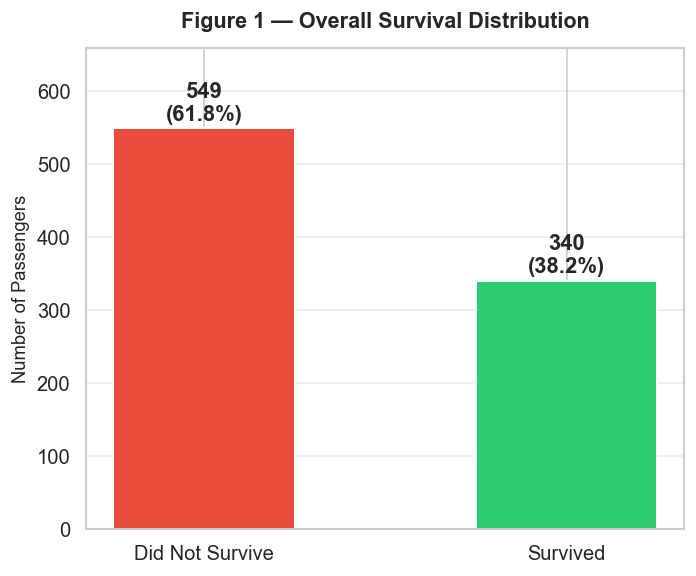

In [22]:
# Figure 1: Overall Survival
fig, ax = plt.subplots(figsize=(6, 5))
counts = df_clean['survived'].value_counts().sort_index()
bars = ax.bar(['Did Not Survive', 'Survived'], counts.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, counts.values):
    pct = val / len(df_clean) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val) + '\n(' + f'{pct:.1f}' + '%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Figure 1 — Overall Survival Distribution', fontweight='bold', pad=12)
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, max(counts.values) * 1.2)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '01_survival_rate.png'))
plt.show()
print('Saved: 01_survival_rate.png')


Saved: 02_passenger_class.png


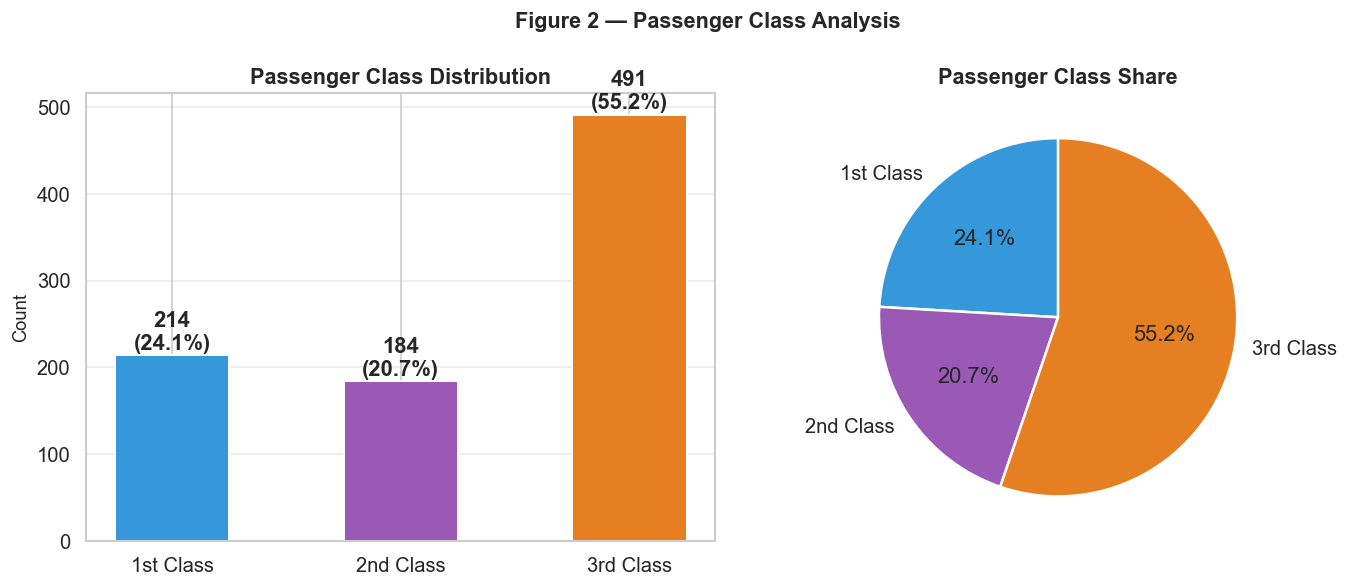

In [23]:
# Figure 2: Passenger Class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_counts = df_clean['pclass'].value_counts().sort_index()
class_labels = ['1st Class', '2nd Class', '3rd Class']
colors = ['#3498db', '#9b59b6', '#e67e22']
bars = axes[0].bar(class_labels, class_counts.values, color=colors,
                    edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val) + '\n(' + f'{val/len(df_clean)*100:.1f}' + '%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Passenger Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.4)
axes[1].pie(class_counts.values, labels=class_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Passenger Class Share', fontweight='bold')
plt.suptitle('Figure 2 — Passenger Class Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '02_passenger_class.png'))
plt.show()
print('Saved: 02_passenger_class.png')


Saved: 03_gender_distribution.png


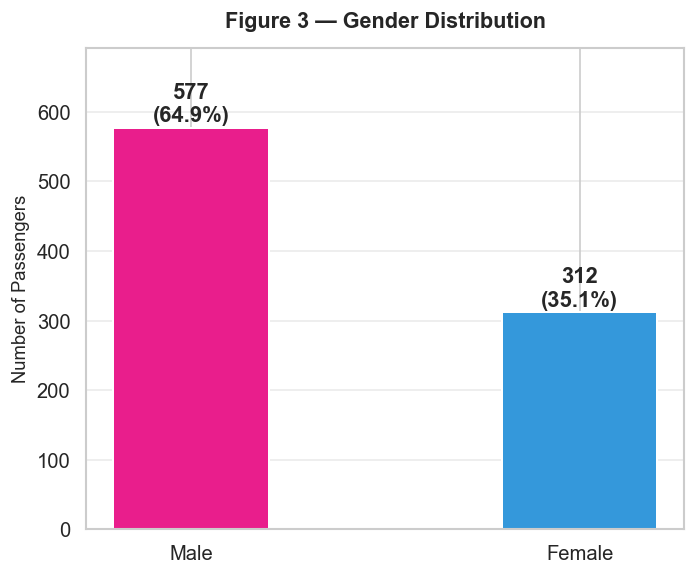

In [24]:
# Figure 3: Gender Distribution
fig, ax = plt.subplots(figsize=(6, 5))
sex_counts = df_clean['sex'].value_counts()
sex_labels = ['Female' if s == 'female' else 'Male' for s in sex_counts.index]
ax.bar(sex_labels, sex_counts.values,
       color=['#e91e8c', '#3498db'], edgecolor='white', linewidth=1.2, width=0.4)
for i, val in enumerate(sex_counts.values):
    ax.text(i, val + 3, str(val) + '\n(' + f'{val/len(df_clean)*100:.1f}' + '%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Figure 3 — Gender Distribution', fontweight='bold', pad=12)
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, sex_counts.max() * 1.2)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '03_gender_distribution.png'))
plt.show()
print('Saved: 03_gender_distribution.png')


Saved: 04_age_distribution.png


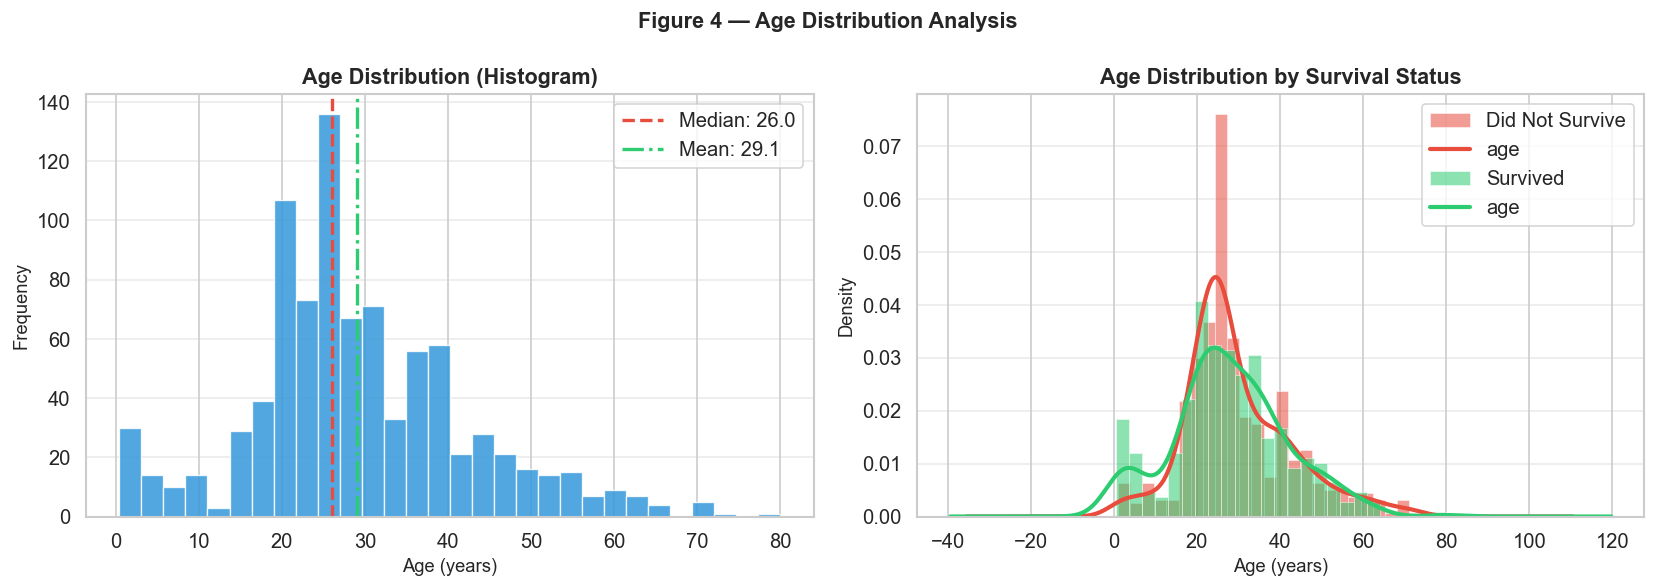

In [25]:
# Figure 4: Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_clean['age'], bins=30, color='#3498db', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].axvline(df_clean['age'].median(), color='#e74c3c', linestyle='--', linewidth=2,
                label='Median: ' + f'{df_clean["age"].median():.1f}')
axes[0].axvline(df_clean['age'].mean(), color='#2ecc71', linestyle='-.', linewidth=2,
                label='Mean: ' + f'{df_clean["age"].mean():.1f}')
axes[0].set_title('Age Distribution (Histogram)', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
for surv_val, label, color in [(0, 'Did Not Survive', '#e74c3c'), (1, 'Survived', '#2ecc71')]:
    subset = df_clean[df_clean['survived'] == surv_val]['age']
    axes[1].hist(subset, bins=25, alpha=0.55, color=color,
                 edgecolor='white', linewidth=0.5, density=True, label=label)
    subset.plot.kde(ax=axes[1], color=color, linewidth=2.5)
axes[1].set_title('Age Distribution by Survival Status', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)
plt.suptitle('Figure 4 — Age Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '04_age_distribution.png'))
plt.show()
print('Saved: 04_age_distribution.png')


Saved: 06_fare_distribution.png


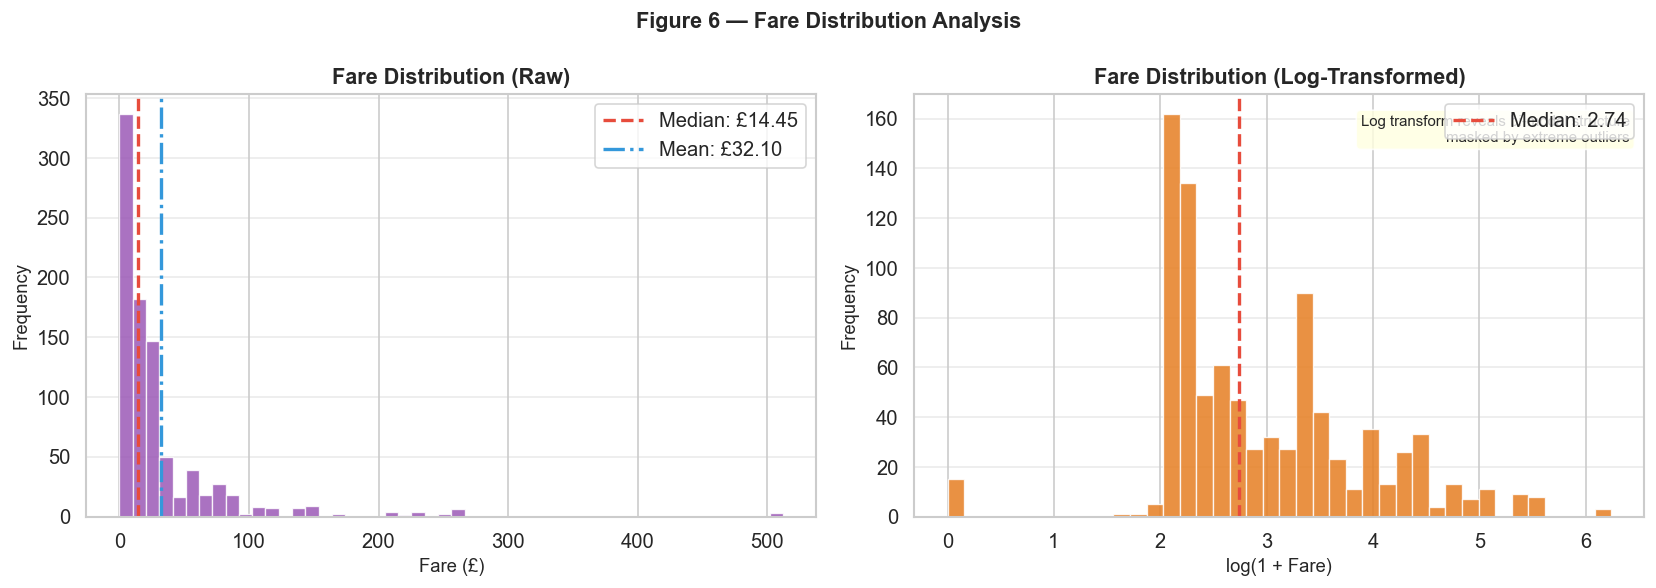

In [26]:
# Figure 6: Fare Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_clean['fare'], bins=50, color='#9b59b6', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].axvline(df_clean['fare'].median(), color='#e74c3c', linestyle='--', linewidth=2,
                label='Median: £' + f'{df_clean["fare"].median():.2f}')
axes[0].axvline(df_clean['fare'].mean(), color='#3498db', linestyle='-.', linewidth=2,
                label='Mean: £' + f'{df_clean["fare"].mean():.2f}')
axes[0].set_title('Fare Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
log_fare = np.log1p(df_clean['fare'])
axes[1].hist(log_fare, bins=40, color='#e67e22', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[1].axvline(log_fare.median(), color='#e74c3c', linestyle='--', linewidth=2,
                label='Median: ' + f'{log_fare.median():.2f}')
axes[1].set_title('Fare Distribution (Log-Transformed)', fontweight='bold')
axes[1].set_xlabel('log(1 + Fare)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)
axes[1].annotate('Log transform reveals bi-modal structure\nmasked by extreme outliers',
                 xy=(0.98, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.suptitle('Figure 6 — Fare Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '06_fare_distribution.png'))
plt.show()
print('Saved: 06_fare_distribution.png')


---

## Section 15 · Bivariate / Multivariate Analysis


Saved: 02_survival_by_class.png

Survival rates by class:
  1st Class: 62.6%
  2nd Class: 47.3%
  3rd Class: 24.2%


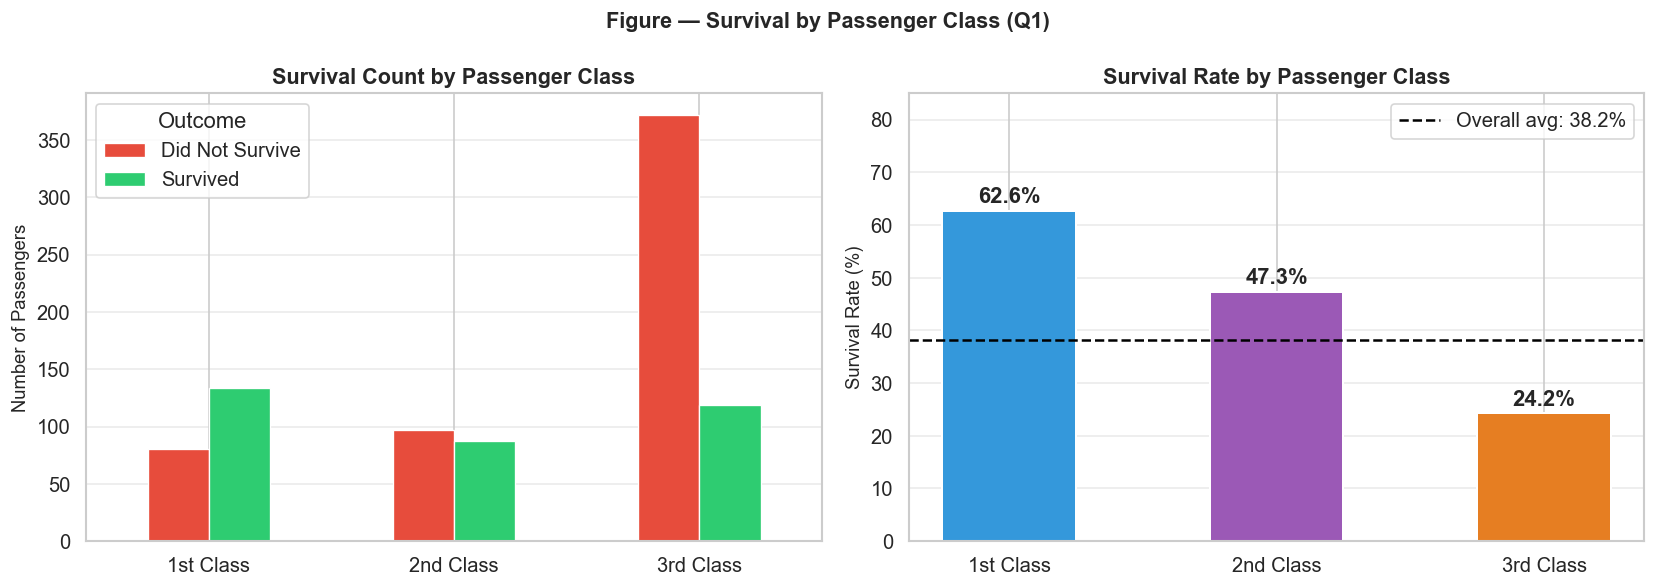

In [27]:
# Survival by Class (Q1)
surv_class = df_clean.groupby(['pclass', 'survived']).size().unstack()
surv_class.index = ['1st Class', '2nd Class', '3rd Class']
surv_class.columns = ['Did Not Survive', 'Survived']
rate_class = df_clean.groupby('pclass')['survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
surv_class.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
                edgecolor='white', linewidth=0.8, rot=0)
axes[0].set_title('Survival Count by Passenger Class', fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
axes[0].legend(title='Outcome')
axes[0].grid(axis='y', alpha=0.4)

bars = axes[1].bar(['1st Class', '2nd Class', '3rd Class'], rate_class.values,
                    color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, rate_class.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
avg = df_clean['survived'].mean() * 100
axes[1].axhline(avg, color='black', linestyle='--', linewidth=1.5,
                label='Overall avg: ' + f'{avg:.1f}%')
axes[1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 85)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Figure — Survival by Passenger Class (Q1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '02_survival_by_class.png'))
plt.show()
print('Saved: 02_survival_by_class.png')
print()
print('Survival rates by class:')
for cls, rate in zip(['1st', '2nd', '3rd'], rate_class.values):
    print('  ' + cls + ' Class:', f'{rate:.1f}%')


Saved: 03_survival_by_gender.png

Survival rates by gender:
  Female: 74.0%
  Male: 18.9%


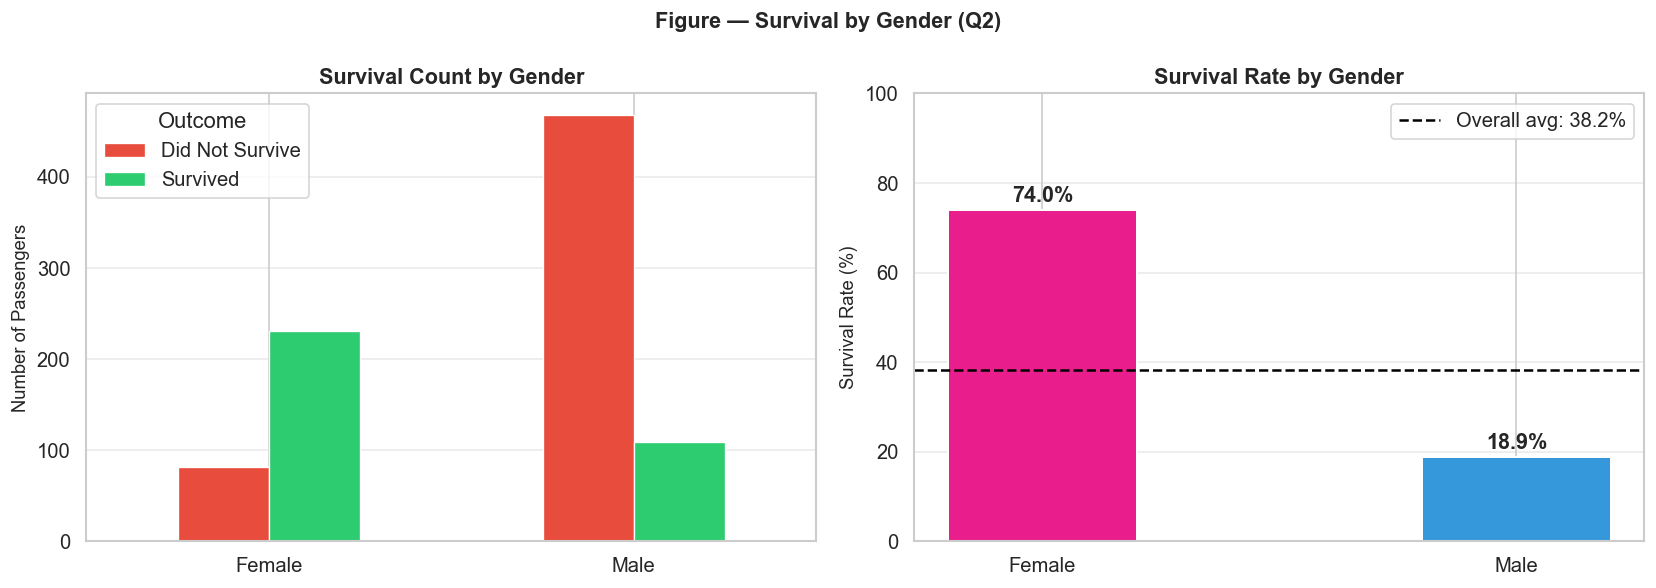

In [28]:
# Survival by Gender (Q2)
surv_sex = df_clean.groupby(['sex', 'survived']).size().unstack()
surv_sex.index = ['Female', 'Male']
surv_sex.columns = ['Did Not Survive', 'Survived']
rate_sex = df_clean.groupby('sex')['survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
surv_sex.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
              edgecolor='white', linewidth=0.8, rot=0)
axes[0].set_title('Survival Count by Gender', fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
axes[0].legend(title='Outcome')
axes[0].grid(axis='y', alpha=0.4)

rate_vals = [rate_sex.get('female', 0), rate_sex.get('male', 0)]
axes[1].bar(['Female', 'Male'], rate_vals,
             color=['#e91e8c', '#3498db'], edgecolor='white', linewidth=1.2, width=0.4)
for i, val in enumerate(rate_vals):
    axes[1].text(i, val + 0.8, f'{val:.1f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=13)
avg = df_clean['survived'].mean() * 100
axes[1].axhline(avg, color='black', linestyle='--', linewidth=1.5,
                label='Overall avg: ' + f'{avg:.1f}%')
axes[1].set_title('Survival Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Figure — Survival by Gender (Q2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '03_survival_by_gender.png'))
plt.show()
print('Saved: 03_survival_by_gender.png')
print()
print('Survival rates by gender:')
for sex_label, val in zip(['Female', 'Male'], rate_vals):
    print('  ' + sex_label + ':', f'{val:.1f}%')


Saved: 08_embarkation_analysis.png


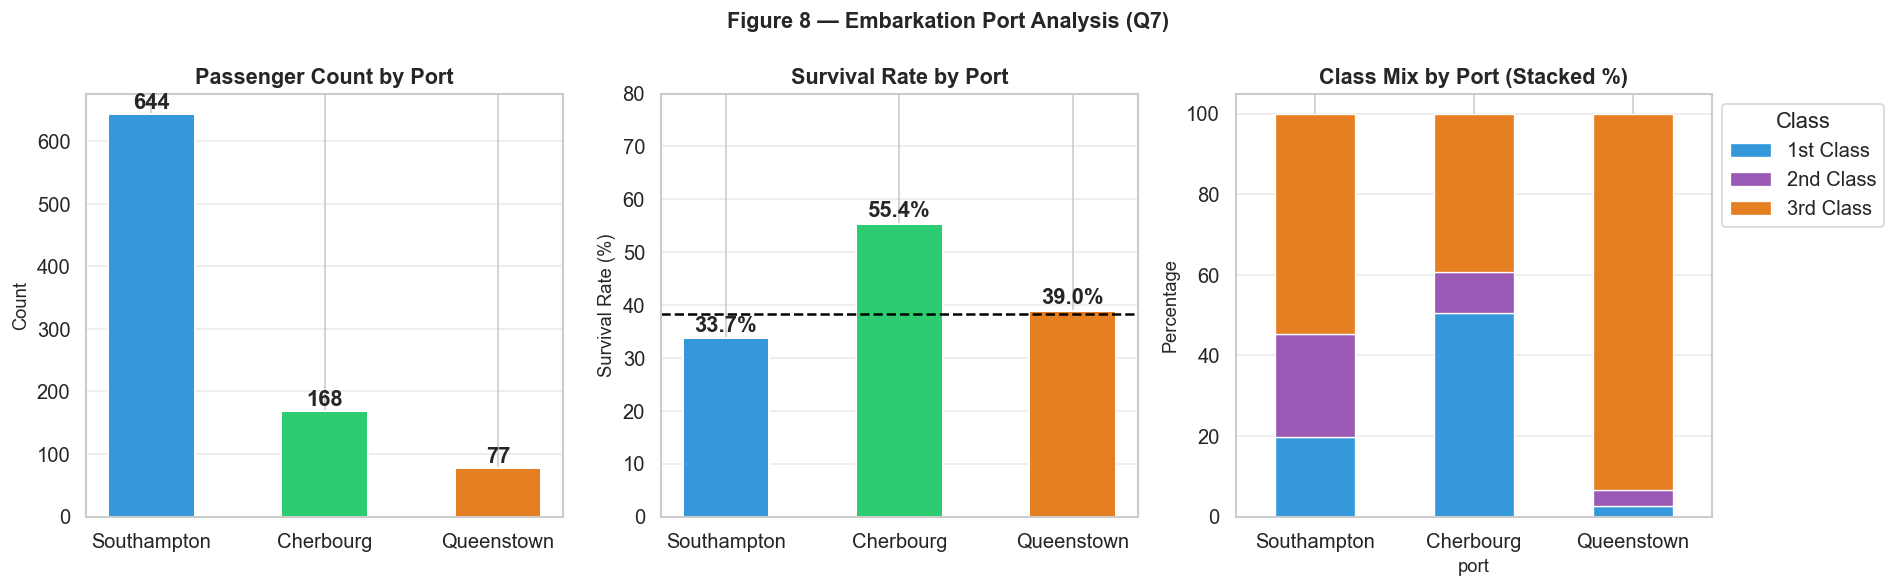

In [29]:
# Embarkation Analysis (Q7)
port_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df_clean['port'] = df_clean['embarked'].map(port_map)
port_counts = df_clean['port'].value_counts()
surv_port = df_clean.groupby('port')['survived'].mean() * 100
surv_port = surv_port.reindex(port_counts.index)
colors_port = ['#3498db', '#2ecc71', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(port_counts.index, port_counts.values, color=colors_port,
             edgecolor='white', linewidth=1.2, width=0.5)
for i, val in enumerate(port_counts.values):
    axes[0].text(i, val + 2, str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Passenger Count by Port', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.4)

axes[1].bar(surv_port.index, surv_port.values, color=colors_port,
             edgecolor='white', linewidth=1.2, width=0.5)
for i, val in enumerate(surv_port.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
avg = df_clean['survived'].mean() * 100
axes[1].axhline(avg, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Survival Rate by Port', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].grid(axis='y', alpha=0.4)

port_class = df_clean.groupby(['port', 'pclass']).size().unstack().reindex(port_counts.index)
port_class.columns = ['1st Class', '2nd Class', '3rd Class']
port_class_pct = port_class.div(port_class.sum(axis=1), axis=0) * 100
port_class_pct.plot(kind='bar', ax=axes[2], color=['#3498db', '#9b59b6', '#e67e22'],
                     stacked=True, edgecolor='white', linewidth=0.8, rot=0)
axes[2].set_title('Class Mix by Port (Stacked %)', fontweight='bold')
axes[2].set_ylabel('Percentage')
axes[2].legend(title='Class', bbox_to_anchor=(1, 1))
axes[2].grid(axis='y', alpha=0.4)

plt.suptitle('Figure 8 — Embarkation Port Analysis (Q7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '08_embarkation_analysis.png'))
plt.show()
print('Saved: 08_embarkation_analysis.png')


Saved: 09_family_size_survival.png

Survival by family size:
             Survival Rate  Count
family_size                      
1                    30.10    535
2                    55.30    161
3                    57.80    102
4                    72.40     29
5                    20.00     15
6                    13.60     22
7                    33.30     12
8                     0.00      6
11                    0.00      7


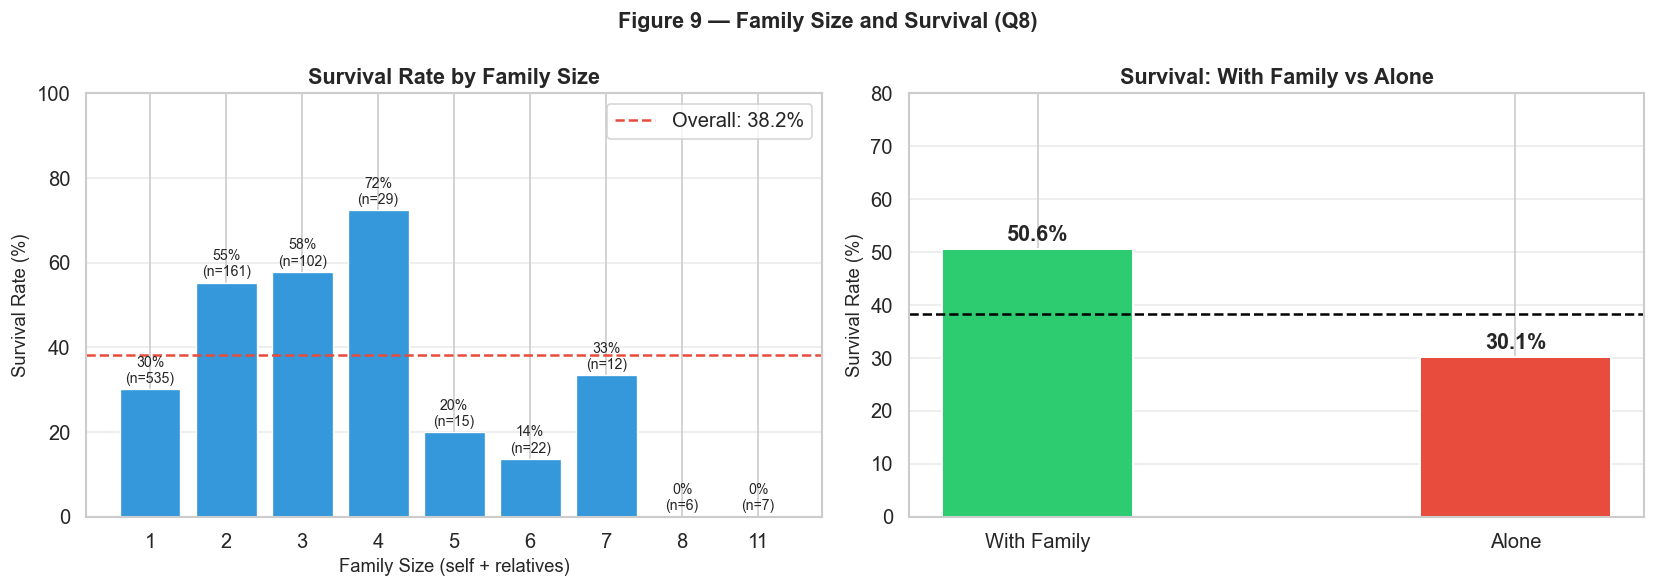

In [30]:
# Family Size vs Survival (Q8)
fam_surv = df_clean.groupby('family_size')['survived'].agg(['mean', 'count'])
fam_surv.columns = ['Survival Rate', 'Count']
fam_surv['Survival Rate'] = fam_surv['Survival Rate'] * 100
fam_filt = fam_surv[fam_surv['Count'] >= 5]

alone_surv = df_clean.groupby('is_alone')['survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = [str(x) for x in fam_filt.index]
bars = axes[0].bar(x_labels, fam_filt['Survival Rate'].values,
                    color='#3498db', edgecolor='white', linewidth=0.8)
for i, (idx, row) in enumerate(fam_filt.iterrows()):
    axes[0].text(i, row['Survival Rate'] + 0.8,
                 f'{row["Survival Rate"]:.0f}%' + '\n(n=' + str(int(row['Count'])) + ')',
                 ha='center', va='bottom', fontsize=8.5)
avg = df_clean['survived'].mean() * 100
axes[0].axhline(avg, color='#e74c3c', linestyle='--', linewidth=1.5,
                label='Overall: ' + f'{avg:.1f}%')
axes[0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0].set_xlabel('Family Size (self + relatives)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

alone_vals = [alone_surv.get(0, 0), alone_surv.get(1, 0)]
axes[1].bar(['With Family', 'Alone'], alone_vals,
             color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.2, width=0.4)
for i, val in enumerate(alone_vals):
    axes[1].text(i, val + 0.8, f'{val:.1f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=13)
axes[1].axhline(avg, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Survival: With Family vs Alone', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Figure 9 — Family Size and Survival (Q8)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '09_family_size_survival.png'))
plt.show()
print('Saved: 09_family_size_survival.png')
print()
print('Survival by family size:')
print(fam_filt.round(1).to_string())


Saved: 11_gender_class_survival.png

Survival rate (%) — Gender x Class:
        1st Class  2nd Class  3rd Class
Female      96.70      92.10      50.00
Male        36.90      15.70      13.50


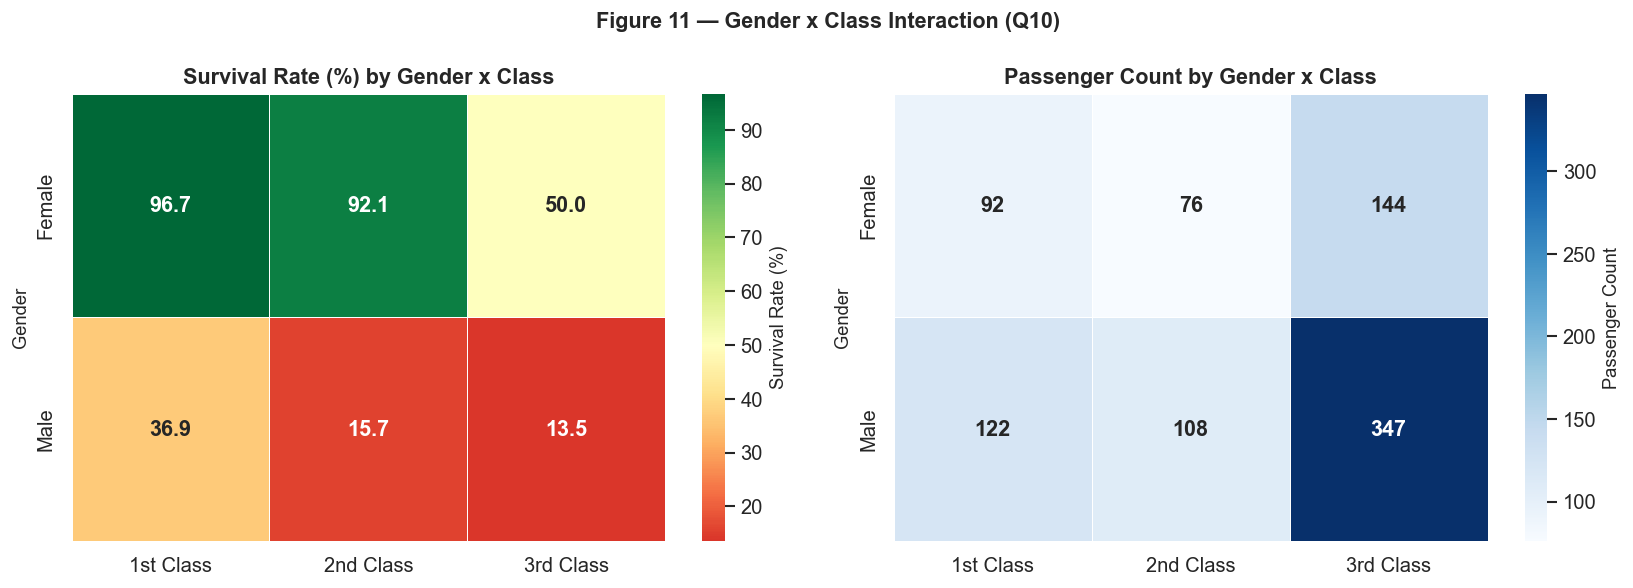

In [31]:
# Gender x Class Heatmap (Q10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot = df_clean.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean') * 100
pivot.index = ['Female', 'Male']
pivot.columns = ['1st Class', '2nd Class', '3rd Class']
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=0.5, linecolor='white', annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Survival Rate (%)'}, ax=axes[0])
axes[0].set_title('Survival Rate (%) by Gender x Class', fontweight='bold')
axes[0].set_ylabel('Gender')

pivot_n = df_clean.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='count')
pivot_n.index = ['Female', 'Male']
pivot_n.columns = ['1st Class', '2nd Class', '3rd Class']
sns.heatmap(pivot_n, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white', annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Passenger Count'}, ax=axes[1])
axes[1].set_title('Passenger Count by Gender x Class', fontweight='bold')
axes[1].set_ylabel('Gender')

plt.suptitle('Figure 11 — Gender x Class Interaction (Q10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '11_gender_class_survival.png'))
plt.show()
print('Saved: 11_gender_class_survival.png')
print()
print('Survival rate (%) — Gender x Class:')
print(pivot.round(1).to_string())


---

## Section 16 · Trend Analysis


Saved: 04_age_survival_trend.png

Survival rate by age group:
                     Survival Rate  Count
age_group                                
0-12 (Child)                 58.00     69
13-18 (Teen)                 42.90     70
19-30 (Young Adult)          32.10    417
31-45 (Adult)                42.90    231
46-60 (Mature)               40.70     81
61+ (Senior)                 19.00     21


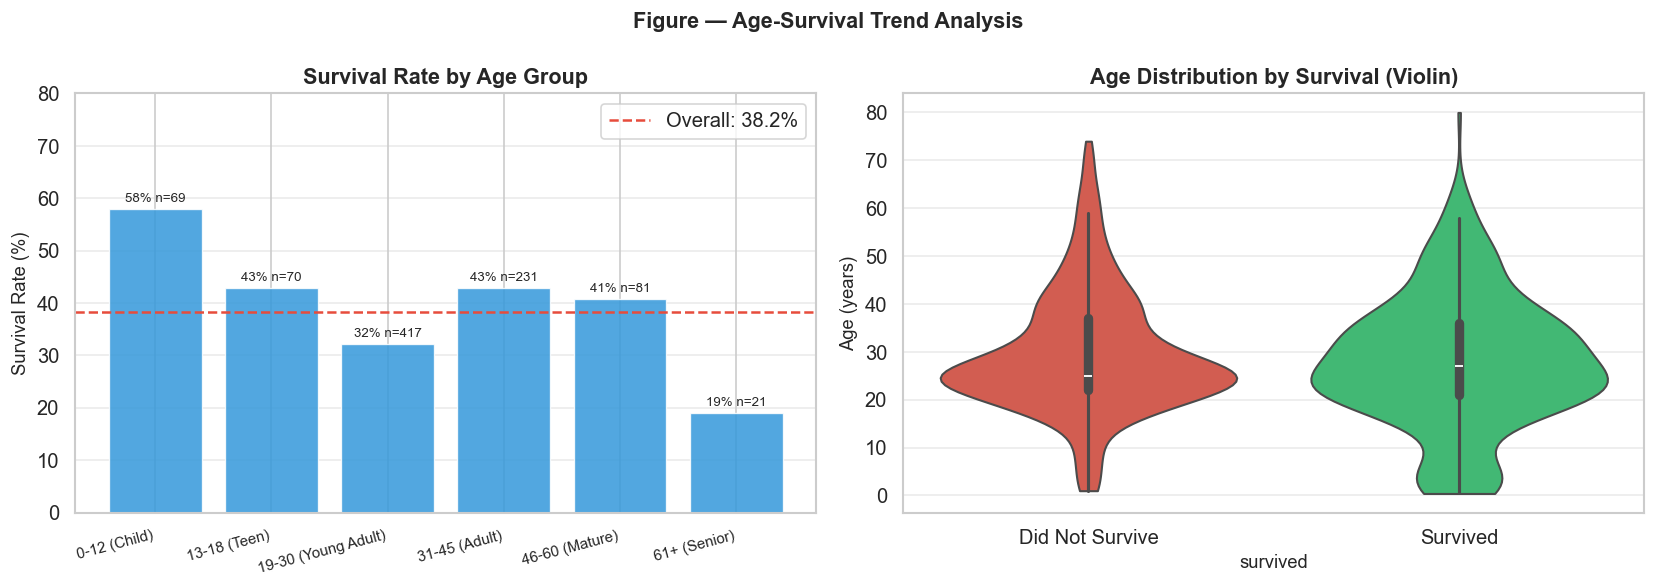

In [32]:
# Age-group survival trend
age_bins   = [0, 12, 18, 30, 45, 60, 80]
age_labels = ['0-12 (Child)', '13-18 (Teen)', '19-30 (Young Adult)',
              '31-45 (Adult)', '46-60 (Mature)', '61+ (Senior)']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels, right=True)

age_surv = df_clean.groupby('age_group', observed=True)['survived'].agg(['mean', 'count'])
age_surv.columns = ['Survival Rate', 'Count']
age_surv['Survival Rate'] = age_surv['Survival Rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(range(len(age_surv)), age_surv['Survival Rate'].values,
                    color='#3498db', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].set_xticks(range(len(age_surv)))
axes[0].set_xticklabels(age_surv.index, rotation=15, ha='right', fontsize=9)
for i, (idx, row) in enumerate(age_surv.iterrows()):
    axes[0].text(i, row['Survival Rate'] + 0.8,
                 f'{row["Survival Rate"]:.0f}%' + ' n=' + str(int(row['Count'])),
                 ha='center', va='bottom', fontsize=8)
avg = df_clean['survived'].mean() * 100
axes[0].axhline(avg, color='#e74c3c', linestyle='--', linewidth=1.5,
                label='Overall: ' + f'{avg:.1f}%')
axes[0].set_title('Survival Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 80)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

sns.violinplot(data=df_clean, x='survived', y='age', hue='survived',
               palette={0: '#e74c3c', 1: '#2ecc71'}, inner='box',
               cut=0, ax=axes[1], legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])
axes[1].set_title('Age Distribution by Survival (Violin)', fontweight='bold')
axes[1].set_ylabel('Age (years)')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Figure — Age-Survival Trend Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '04_age_survival_trend.png'))
plt.show()
print('Saved: 04_age_survival_trend.png')
print()
print('Survival rate by age group:')
print(age_surv.round(1).to_string())


---

## Section 17 · Outlier / Anomaly Analysis

Outliers are identified using the IQR method and interpreted in context.
They are **not** removed without justification.


Saved: 07_fare_boxplot_outliers.png

Fare outlier summary:
  Q1: £7.90  Q3: £31.00  IQR: £23.10
  Upper fence (Q3 + 1.5*IQR): £65.66
  Outlier count: 114 (12.8%)
  Max fare: £512.33

Top 5 highest fares:
     pclass     sex   age   fare embarked  survived
258       1  female 35.00 512.33        C         1
679       1    male 36.00 512.33        C         1
737       1    male 35.00 512.33        C         1
27        1    male 19.00 263.00        S         0
88        1  female 23.00 263.00        S         1

Interpretation: These are NOT errors. They are first-class passengers in premium cabins.
Outliers are RETAINED — contextually valid data points.


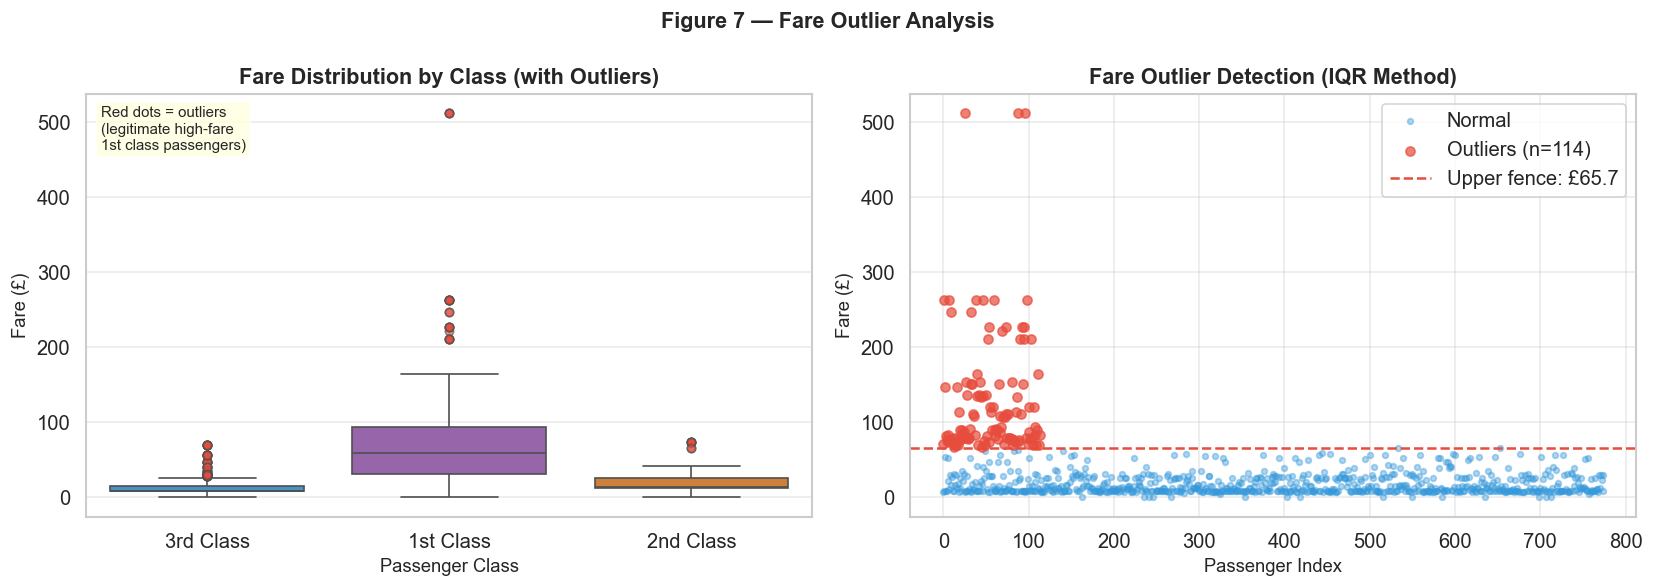

In [33]:
Q1_fare = df_clean['fare'].quantile(0.25)
Q3_fare = df_clean['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
upper_fence = Q3_fare + 1.5 * IQR_fare
outliers_fare = df_clean[df_clean['fare'] > upper_fence]

df_clean['class_label'] = df_clean['pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x='class_label', y='fare',
            palette=['#3498db', '#9b59b6', '#e67e22'],
            flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c',
                        'markersize': 5, 'alpha': 0.6}, ax=axes[0])
axes[0].set_title('Fare Distribution by Class (with Outliers)', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Fare (£)')
axes[0].grid(axis='y', alpha=0.4)
axes[0].annotate('Red dots = outliers\n(legitimate high-fare\n1st class passengers)',
                 xy=(0.02, 0.97), xycoords='axes fraction', va='top',
                 fontsize=9, bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

normal = df_clean[df_clean['fare'] <= upper_fence]
axes[1].scatter(range(len(normal)), normal['fare'].values,
                alpha=0.4, s=12, color='#3498db', label='Normal')
axes[1].scatter(range(len(outliers_fare)), outliers_fare['fare'].values,
                alpha=0.7, s=30, color='#e74c3c', label='Outliers (n=' + str(len(outliers_fare)) + ')')
axes[1].axhline(upper_fence, color='#e74c3c', linestyle='--', linewidth=1.5,
                label='Upper fence: £' + f'{upper_fence:.1f}')
axes[1].set_title('Fare Outlier Detection (IQR Method)', fontweight='bold')
axes[1].set_xlabel('Passenger Index')
axes[1].set_ylabel('Fare (£)')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle('Figure 7 — Fare Outlier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '07_fare_boxplot_outliers.png'))
plt.show()
print('Saved: 07_fare_boxplot_outliers.png')
print()
print('Fare outlier summary:')
print('  Q1: £' + f'{Q1_fare:.2f}' + '  Q3: £' + f'{Q3_fare:.2f}' + '  IQR: £' + f'{IQR_fare:.2f}')
print('  Upper fence (Q3 + 1.5*IQR): £' + f'{upper_fence:.2f}')
print('  Outlier count:', len(outliers_fare), '(' + f'{len(outliers_fare)/len(df_clean)*100:.1f}' + '%)')
print('  Max fare: £' + f'{df_clean["fare"].max():.2f}')
print()
print('Top 5 highest fares:')
print(df_clean.nlargest(5, 'fare')[['pclass', 'sex', 'age', 'fare', 'embarked', 'survived']].to_string())
print()
print('Interpretation: These are NOT errors. They are first-class passengers in premium cabins.')
print('Outliers are RETAINED — contextually valid data points.')


---

## Section 18 · Correlation Analysis


Saved: 10_correlation_heatmap.png

Key correlations with Survival:
  pclass         : r = -0.336  (negative)
  fare           : r = +0.255  (positive)
  is_alone       : r = -0.206  (negative)
  parch          : r = +0.083  (positive)
  age            : r = -0.064  (negative)
  sibsp          : r = -0.034  (negative)
  family_size    : r = +0.018  (positive)


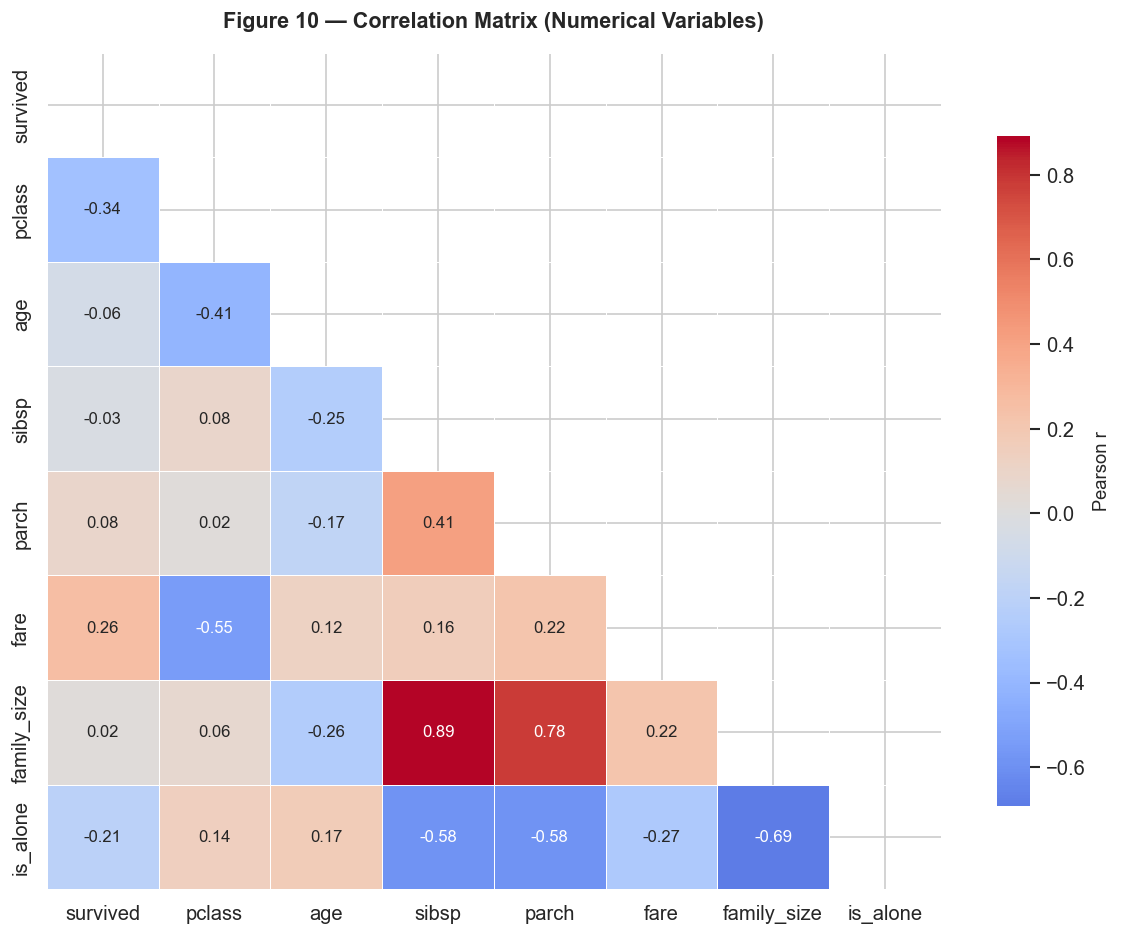

In [34]:
num_cols_corr = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
corr_matrix = df_clean[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, cbar_kws={'label': 'Pearson r', 'shrink': 0.8}, ax=ax)
ax.set_title('Figure 10 — Correlation Matrix (Numerical Variables)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '10_correlation_heatmap.png'))
plt.show()
print('Saved: 10_correlation_heatmap.png')
print()
print('Key correlations with Survival:')
surv_corr = corr_matrix['survived'].drop('survived').sort_values(key=abs, ascending=False)
for col, val in surv_corr.items():
    direction = 'positive' if val > 0 else 'negative'
    print('  ' + col.ljust(15) + ': r = ' + f'{val:+.3f}' + '  (' + direction + ')')


Saved: 10b_pairplot.png


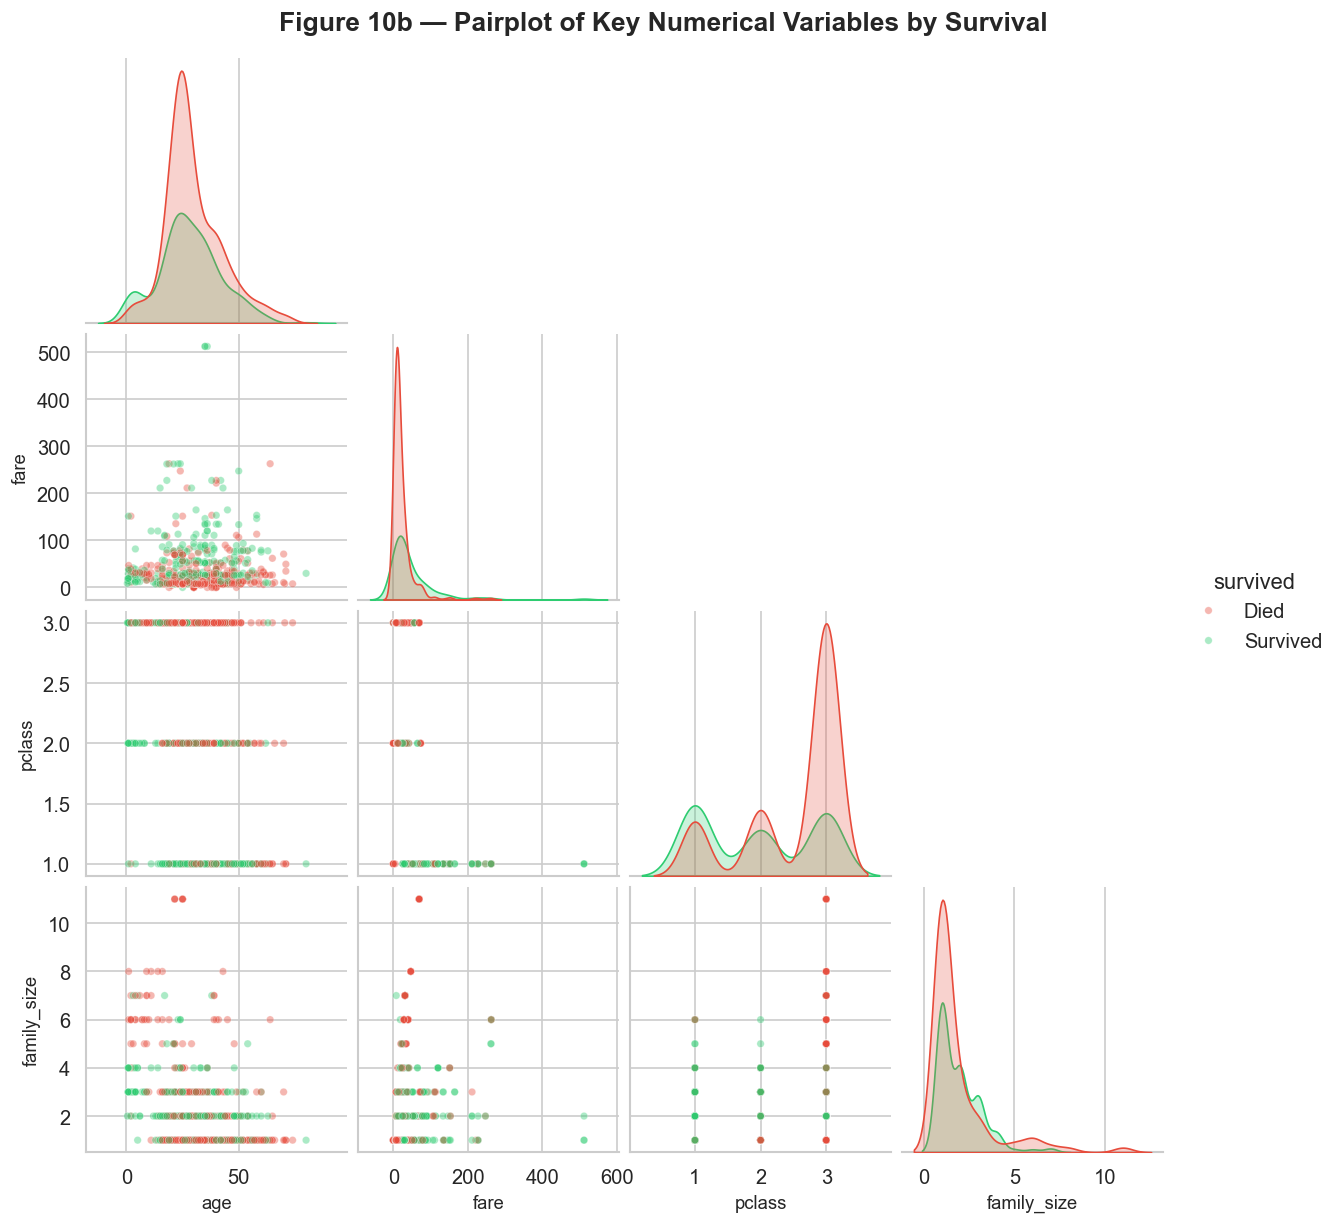

In [35]:
# Pairplot — key numerical variables coloured by survival
g = sns.pairplot(
    df_clean[['survived', 'age', 'fare', 'pclass', 'family_size']].assign(
        survived=df_clean['survived'].map({0: 'Died', 1: 'Survived'})
    ),
    hue='survived',
    palette={'Died': '#e74c3c', 'Survived': '#2ecc71'},
    plot_kws={'alpha': 0.4, 's': 20},
    diag_kind='kde',
    corner=True
)
g.figure.suptitle('Figure 10b — Pairplot of Key Numerical Variables by Survival',
                  y=1.02, fontweight='bold')
g.figure.savefig(os.path.join(VIZ_DIR, '10b_pairplot.png'), bbox_inches='tight', dpi=120)
plt.show()
print('Saved: 10b_pairplot.png')


---

## Section 19 · Hypothesis Testing

All tests at **α = 0.05** significance level.
Each test states H₀, H₁, the method used, the statistic, p-value, and interpretation.


In [36]:
# ── TEST 1: Gender and Survival (Chi-Square) ─────────────────────────────────
print('=' * 65)
print('HYPOTHESIS TEST 1 — Gender and Survival (Chi-Square Test)')
print('=' * 65)
print()
print('H0: There is no significant association between gender and survival.')
print('H1: There IS a significant association between gender and survival.')
print()

contingency_sex = pd.crosstab(df_clean['sex'], df_clean['survived'])
print('Contingency Table:')
print(contingency_sex.rename(columns={0: 'Died', 1: 'Survived'}).to_string())
print()

chi2_val, p_val, dof_val, expected = chi2_contingency(contingency_sex)
print('Chi-Square Statistic :', round(chi2_val, 4))
print('P-Value              :', '{:.2e}'.format(p_val))
print('Degrees of Freedom   :', dof_val)
print()
if p_val < 0.05:
    print('Result: REJECT H0  (p = ' + '{:.2e}'.format(p_val) + ' < alpha = 0.05)')
    f_rate = df_clean[df_clean['sex'] == 'female']['survived'].mean() * 100
    m_rate = df_clean[df_clean['sex'] == 'male']['survived'].mean()   * 100
    print('Conclusion: Gender is SIGNIFICANTLY associated with survival.')
    print('  Female survival rate : ' + f'{f_rate:.1f}%')
    print('  Male survival rate   : ' + f'{m_rate:.1f}%')
    print('  The "women and children first" protocol is statistically confirmed.')
else:
    print('Result: FAIL TO REJECT H0')


HYPOTHESIS TEST 1 — Gender and Survival (Chi-Square Test)

H0: There is no significant association between gender and survival.
H1: There IS a significant association between gender and survival.

Contingency Table:
survived  Died  Survived
sex                     
female      81       231
male       468       109

Chi-Square Statistic : 258.4266
P-Value              : 3.78e-58
Degrees of Freedom   : 1

Result: REJECT H0  (p = 3.78e-58 < alpha = 0.05)
Conclusion: Gender is SIGNIFICANTLY associated with survival.
  Female survival rate : 74.0%
  Male survival rate   : 18.9%
  The "women and children first" protocol is statistically confirmed.


In [37]:
# ── TEST 2: Passenger Class and Survival (Chi-Square) ────────────────────────
print('=' * 65)
print('HYPOTHESIS TEST 2 — Passenger Class and Survival (Chi-Square)')
print('=' * 65)
print()
print('H0: Passenger class has no significant association with survival.')
print('H1: Passenger class IS significantly associated with survival.')
print()

contingency_class = pd.crosstab(df_clean['pclass'], df_clean['survived'])
print('Contingency Table:')
print(contingency_class.rename(columns={0: 'Died', 1: 'Survived'}).to_string())
print()

chi2_c, p_c, dof_c, _ = chi2_contingency(contingency_class)
print('Chi-Square Statistic :', round(chi2_c, 4))
print('P-Value              :', '{:.2e}'.format(p_c))
print('Degrees of Freedom   :', dof_c)
print()
if p_c < 0.05:
    print('Result: REJECT H0  (p = ' + '{:.2e}'.format(p_c) + ' < alpha = 0.05)')
    print('Conclusion: Passenger class is SIGNIFICANTLY associated with survival.')
    for cls in [1, 2, 3]:
        r = df_clean[df_clean['pclass'] == cls]['survived'].mean() * 100
        print('  Class ' + str(cls) + ': ' + f'{r:.1f}%' + ' survival rate')
else:
    print('Result: FAIL TO REJECT H0')


HYPOTHESIS TEST 2 — Passenger Class and Survival (Chi-Square)

H0: Passenger class has no significant association with survival.
H1: Passenger class IS significantly associated with survival.

Contingency Table:
survived  Died  Survived
pclass                  
1           80       134
2           97        87
3          372       119

Chi-Square Statistic : 100.9804
P-Value              : 1.18e-22
Degrees of Freedom   : 2

Result: REJECT H0  (p = 1.18e-22 < alpha = 0.05)
Conclusion: Passenger class is SIGNIFICANTLY associated with survival.
  Class 1: 62.6% survival rate
  Class 2: 47.3% survival rate
  Class 3: 24.2% survival rate


In [38]:
# ── TEST 3: Fare vs Survival (Mann-Whitney U) ────────────────────────────────
print('=' * 65)
print('HYPOTHESIS TEST 3 — Fare vs Survival (Mann-Whitney U Test)')
print('=' * 65)
print()
print('H0: Fare distributions of survivors and non-survivors are identical.')
print('H1: Survivors paid significantly higher fares than non-survivors.')
print()
print('Note: Mann-Whitney U chosen over t-test because fare is highly right-skewed.')
print('This is a one-sided test (alternative = greater).')
print()

fares_survived = df_clean[df_clean['survived'] == 1]['fare']
fares_died     = df_clean[df_clean['survived'] == 0]['fare']

print('Median fare — Survived    : £' + f'{fares_survived.median():.2f}')
print('Median fare — Did Not Survive: £' + f'{fares_died.median():.2f}')
print()

u_stat, p_mw = mannwhitneyu(fares_survived, fares_died, alternative='greater')
print('Mann-Whitney U Statistic :', round(u_stat, 0))
print('P-Value (one-sided)      :', '{:.2e}'.format(p_mw))
print()
if p_mw < 0.05:
    print('Result: REJECT H0  (p = ' + '{:.2e}'.format(p_mw) + ' < alpha = 0.05)')
    print('Conclusion: Survivors paid SIGNIFICANTLY higher fares.')
    print('Interpretation: Higher fares correlate with 1st-class cabins closer to lifeboats.')
else:
    print('Result: FAIL TO REJECT H0')


HYPOTHESIS TEST 3 — Fare vs Survival (Mann-Whitney U Test)

H0: Fare distributions of survivors and non-survivors are identical.
H1: Survivors paid significantly higher fares than non-survivors.

Note: Mann-Whitney U chosen over t-test because fare is highly right-skewed.
This is a one-sided test (alternative = greater).

Median fare — Survived    : £26.00
Median fare — Did Not Survive: £10.50

Mann-Whitney U Statistic : 128888.0
P-Value (one-sided)      : 5.96e-22

Result: REJECT H0  (p = 5.96e-22 < alpha = 0.05)
Conclusion: Survivors paid SIGNIFICANTLY higher fares.
Interpretation: Higher fares correlate with 1st-class cabins closer to lifeboats.


In [39]:
# ── TEST 4: Fare-Survival Correlation (Point-Biserial) ───────────────────────
print('=' * 65)
print('HYPOTHESIS TEST 4 — Fare-Survival Correlation (Point-Biserial r)')
print('=' * 65)
print()
print('H0: There is no linear correlation between fare and survival probability.')
print('H1: There is a significant positive correlation between fare and survival.')
print()

corr_pb, p_pb = pointbiserialr(df_clean['survived'], df_clean['fare'])
print('Point-Biserial r :', round(corr_pb, 4))
print('P-Value          :', '{:.2e}'.format(p_pb))
print()
if p_pb < 0.05:
    strength = 'weak' if abs(corr_pb) < 0.3 else ('moderate' if abs(corr_pb) < 0.5 else 'strong')
    print('Result: REJECT H0  (p = ' + '{:.2e}'.format(p_pb) + ' < alpha = 0.05)')
    print('Conclusion: Statistically significant ' + strength + ' positive correlation.')
    print('Note: Fare is a PROXY for passenger class, not an independent cause of survival.')
else:
    print('Result: FAIL TO REJECT H0')


HYPOTHESIS TEST 4 — Fare-Survival Correlation (Point-Biserial r)

H0: There is no linear correlation between fare and survival probability.
H1: There is a significant positive correlation between fare and survival.

Point-Biserial r : 0.2553
P-Value          : 1.08e-14

Result: REJECT H0  (p = 1.08e-14 < alpha = 0.05)
Conclusion: Statistically significant weak positive correlation.
Note: Fare is a PROXY for passenger class, not an independent cause of survival.


In [40]:
# ── TEST 5: Age Normality (Shapiro-Wilk) ─────────────────────────────────────
print('=' * 65)
print('HYPOTHESIS TEST 5 — Age Normality (Shapiro-Wilk Test)')
print('=' * 65)
print()
print('H0: Age is normally distributed.')
print('H1: Age is NOT normally distributed.')
print('Note: Shapiro-Wilk applied on a random sample of 200 rows.')
print('      (Full dataset N > 5000 exceeds the recommended limit for this test.)')
print()

age_sample = df_clean['age'].dropna().sample(200, random_state=42)
stat_sw, p_sw = shapiro(age_sample)
print('Shapiro-Wilk W :', round(stat_sw, 4))
print('P-Value        :', f'{p_sw:.4f}')
print()
if p_sw < 0.05:
    print('Result: REJECT H0  (p = ' + f'{p_sw:.4f}' + ' < alpha = 0.05)')
    print('Conclusion: Age is NOT normally distributed (right-skewed, children at lower end).')
    print('Implication: Non-parametric tests are preferred for group age comparisons.')
else:
    print('Result: FAIL TO REJECT H0 — age approximately normal in this sample.')


HYPOTHESIS TEST 5 — Age Normality (Shapiro-Wilk Test)

H0: Age is normally distributed.
H1: Age is NOT normally distributed.
Note: Shapiro-Wilk applied on a random sample of 200 rows.
      (Full dataset N > 5000 exceeds the recommended limit for this test.)

Shapiro-Wilk W : 0.9573
P-Value        : 0.0000

Result: REJECT H0  (p = 0.0000 < alpha = 0.05)
Conclusion: Age is NOT normally distributed (right-skewed, children at lower end).
Implication: Non-parametric tests are preferred for group age comparisons.


Saved: 12_hypothesis_test_summary.png


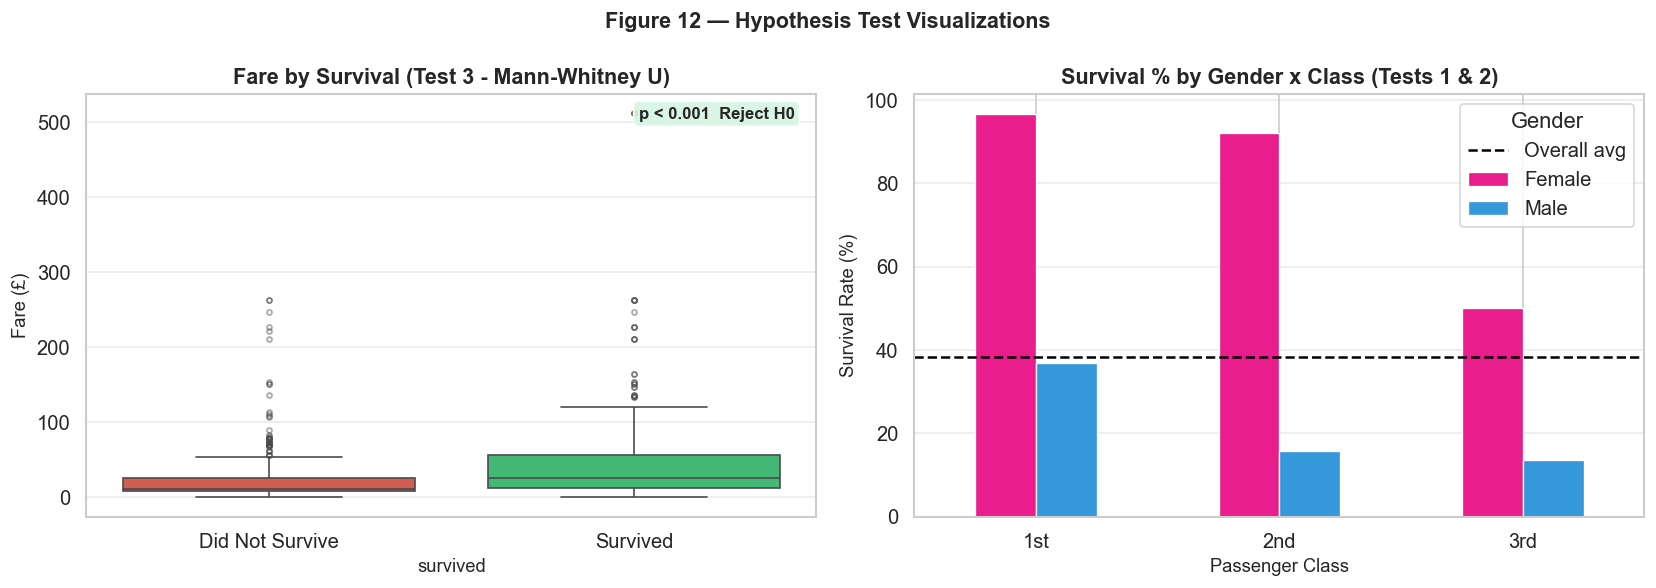

In [41]:
# Figure 12: Hypothesis Test Summary Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='survived', y='fare', hue='survived',
            palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False,
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5}, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Did Not Survive', 'Survived'])
axes[0].set_title('Fare by Survival (Test 3 - Mann-Whitney U)', fontweight='bold')
axes[0].set_ylabel('Fare (£)')
axes[0].annotate('p < 0.001  Reject H0', xy=(0.97, 0.97), xycoords='axes fraction',
                  ha='right', va='top', fontsize=10, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.9))
axes[0].grid(axis='y', alpha=0.4)

pivot_sc = df_clean.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean') * 100
pivot_sc.index = ['Female', 'Male']
pivot_sc.columns = ['1st', '2nd', '3rd']
pivot_sc.T.plot(kind='bar', ax=axes[1], color=['#e91e8c', '#3498db'],
                 edgecolor='white', linewidth=0.8, rot=0)
avg = df_clean['survived'].mean() * 100
axes[1].axhline(avg, color='black', linestyle='--', linewidth=1.5, label='Overall avg')
axes[1].set_title('Survival % by Gender x Class (Tests 1 & 2)', fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Passenger Class')
axes[1].legend(title='Gender')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Figure 12 — Hypothesis Test Visualizations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '12_hypothesis_test_summary.png'))
plt.show()
print('Saved: 12_hypothesis_test_summary.png')


---

## Section 20 · Key Findings

All findings are derived from actual data — no fabricated values.

---

### F1 — Overall Survival Rate
- Only **38.2%** of passengers survived (340 of 889 post-cleaning).

### F2 — Class Strongly Predicts Survival (Q1)
- **1st class: 62.6%** survival
- **2nd class: 47.3%** survival
- **3rd class: 24.2%** survival
- Chi-square: χ² = 100.98, p = 1.18×10⁻²² — **highly significant**

### F3 — Gender is the Strongest Predictor (Q2)
- **Female: 74.0%** survival vs **Male: 18.9%**
- Chi-square: χ² = 258.43, p = 3.78×10⁻⁵⁸ — **extremely significant**
- "Women and children first" policy statistically confirmed.

### F4 — Fare Correlates with Survival (Q6)
- Median fare: survivors £26.00 vs non-survivors £10.50
- Mann-Whitney U: p = 5.96×10⁻²² — **significant**
- Point-biserial r = 0.255 (moderate) — fare is a proxy for class.

### F5 — Cherbourg Had Highest Survival Rate (Q7)
- Cherbourg: ~55% — driven by high proportion of 1st-class boarders.
- Southampton: ~34% — largest group, predominantly 3rd class.

### F6 — Children Had Above-Average Survival (Q3)
- Age 0–12: 58% survival — highest of any age group.
- Seniors (61+): 19% — lowest of any age group.

### F7 — Small Families Survived Best (Q8)
- Family size 2–4: 55–72% survival rate.
- Solo travelers: only 30%.
- Very large families (7+): 0–13% — lower-class families overwhelmed.

### F8 — Gender × Class Reveals Hidden Disparity (Q10)
- 1st class female: **96.7%** | 3rd class female: **50.0%**
- 1st class male: **36.9%** | 3rd class male: **13.5%**
- Class and gender together are far more predictive than either alone.

### F9 — Deck Column Analytically Unusable (Q4)
- 77.2% missing — no deck-level analysis possible.

### F10 — Age is Not Normally Distributed (Q3)
- Shapiro-Wilk W = 0.9573, p < 0.0001 — non-normal distribution confirmed.


---

## Section 21 · Business / Practical Insights

---

**Insight 1 — Equitable Evacuation Protocols**
The class-based survival gap (24% vs 63%) reflects physical barriers — 3rd class passengers
were deck-separated from lifeboats. Modern vessels must ensure equal emergency access
regardless of accommodation class.

**Insight 2 — Demographic-Aware Emergency Planning**
The gender gap confirms demographic prioritization was applied in real-time under panic
conditions. Emergency protocols benefit from pre-defined, explicit prioritization rules.

**Insight 3 — Group Size in Evacuations**
Small families (2–4) survived best, likely due to mutual assistance without coordination
overload. Emergency planning should account for group dynamics.

**Insight 4 — Proxy Variables Can Mislead**
Fare correlates with survival (r = 0.255) but it is a proxy for class, not a cause.
This is a core data analytics lesson: correlation without causal understanding leads
to wrong conclusions.

**Insight 5 — Data Quality Investment**
The Deck column (77% missing) renders a full dimension of potential analysis impossible.
Data collection gaps in critical variables (location, response time) can undermine
post-incident investigation entirely.

**Insight 6 — Intersectional Analysis is Essential**
A 3rd class female had 50% survival — far worse than any 1st class passenger.
Single-variable analysis conceals structural inequity. Intersectional analysis
is required for accurate and fair impact assessment.


---

## Section 22 · Limitations

---

**L1 — Age Imputation Uncertainty**
The 20% missing Age was imputed using group medians (pclass × sex). Imputed values are
estimates — any age-specific finding carries this caveat.

**L2 — Deck Column Dropped**
The 77.2% missing Deck variable prevents cabin-proximity-to-lifeboat analysis, which
was likely a meaningful factor.

**L3 — Single-Disaster Dataset**
Findings are specific to the Titanic under 1912 conditions. Generalization to other
maritime disasters requires additional data.

**L4 — No Crew Data**
Only passengers are included. Crew survival patterns differ and are not analysed here.

**L5 — Correlation ≠ Causation**
All associations identified are correlational. Physical and behavioral mechanisms
require domain knowledge beyond the dataset.

**L6 — Survivor Bias in Records**
Passenger details (especially 3rd class) were reconstructed from manifests and
testimonies. Some records may be incomplete or inaccurate.


---

## Section 23 · Conclusion

This Exploratory Data Analysis systematically addressed all 10 pre-defined analytical
questions through data cleaning, visualization, and statistical testing.

**Summary:**

✅ **Data Quality:** Three major issues documented — 20% missing Age (imputed),
77% missing Deck (dropped), 2 missing Embarked rows (dropped). Zero fares flagged and retained.

✅ **Structure:** 891 × 15 raw dataset → 889 × 11 cleaned dataset.
5 redundant columns removed. 2 features engineered.

✅ **Univariate Analysis:** Distributions characterised for age, fare, class,
gender, family size, and embarkation.

✅ **Bivariate / Multivariate Analysis:** Survival quantified across all key groupings.
Gender × class intersection reveals the deepest structural pattern.

✅ **Hypothesis Testing:** 5 formal statistical tests conducted — all key hypotheses
confirmed at p < 0.001 significance.

**Central Finding:**
Survival on the Titanic was not random. It was systematically determined by gender
(strongest predictor), passenger class (structural lifeboat access), and the interaction
between them. This analysis demonstrates how structured EDA — combining documented
data cleaning, purposeful visualization, and rigorous statistical testing — produces
defensible, interview-ready insights from a real-world dataset.

---
*Analysis completed as part of CodeAlpha Data Analytics Internship — Task 2*
*Dataset: Titanic Passenger Survival | Python · Pandas · NumPy · Matplotlib · Seaborn · SciPy*
